20240505 permutation更改为100,000次

20240911 Gratitude数据修改为Mix，6Onset

20241103 Gratitude

20241106 all data run 6onset version

In [1]:
from nltools.data import Adjacency
from nltools.mask import expand_mask, collapse_mask
from nltools.data import Brain_Data
from sklearn.metrics import pairwise_distances
import seaborn as sns
import numpy as np
import glob
import pandas as pd
import os
import matplotlib as mpl
import scipy
%matplotlib inline
from nltools.stats import fdr, threshold, fisher_r_to_z, one_sample_permutation
from nilearn.plotting import plot_glass_brain, plot_stat_map
from sklearn.metrics import pairwise_distances
from nilearn import image
import progressbar
import csv
import nltools

In [2]:
print(nltools.__file__)

c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\nltools\__init__.py


In [3]:
import nltools
nltools.__version__

'0.5.1'

In [9]:
raw_dir = 'E:\\lxq\\jupyter\\CMF2024\\fmri\\03_rsa\\'
nii_dir = raw_dir + 'rsa_nii\\01_nii\\nii_6onset\\'

behavioral_filename = 'rsa_nii\\behavior_condi_info_241103.xlsx'

results_dir = raw_dir + '241106_rsa_6Onset\\WSRSA_condition_results_241106_6Onset\\'

if os.path.exists(results_dir):
    print("distance_dir路径存在")
else:
    print("distance_dir路径不存在")

distance_dir路径存在


'E:\\lxq\\jupyter\\CMF2024\\fmri\\03_rsa\\241106_rsa_6Onset\\WSRSA_condition_results_241106_6Onset\\'

# Read Data

In [10]:
niis_list = glob.glob(os.path.join(nii_dir,'s*.nii'))

In [11]:
print(len(list(np.sort(niis_list))))
list(np.sort(niis_list))

276


['E:\\lxq\\jupyter\\CMF2024\\fmri\\03_rsa\\rsa_nii\\01_nii\\nii_6onset\\sub7001_con_0164_Outcome_Post_RTwo_Help.nii',
 'E:\\lxq\\jupyter\\CMF2024\\fmri\\03_rsa\\rsa_nii\\01_nii\\nii_6onset\\sub7001_con_0166_Outcome_Post_REight_Help.nii',
 'E:\\lxq\\jupyter\\CMF2024\\fmri\\03_rsa\\rsa_nii\\01_nii\\nii_6onset\\sub7001_con_0172_Decision_Risk_Help.nii',
 'E:\\lxq\\jupyter\\CMF2024\\fmri\\03_rsa\\rsa_nii\\01_nii\\nii_6onset\\sub7001_con_0174_Decision_CTwo_Help.nii',
 'E:\\lxq\\jupyter\\CMF2024\\fmri\\03_rsa\\rsa_nii\\01_nii\\nii_6onset\\sub7001_con_0176_Decision_CFive_Help.nii',
 'E:\\lxq\\jupyter\\CMF2024\\fmri\\03_rsa\\rsa_nii\\01_nii\\nii_6onset\\sub7001_con_0178_Decision_CEight_Help.nii',
 'E:\\lxq\\jupyter\\CMF2024\\fmri\\03_rsa\\rsa_nii\\01_nii\\nii_6onset\\sub7002_con_0164_Outcome_Post_RTwo_Help.nii',
 'E:\\lxq\\jupyter\\CMF2024\\fmri\\03_rsa\\rsa_nii\\01_nii\\nii_6onset\\sub7002_con_0166_Outcome_Post_REight_Help.nii',
 'E:\\lxq\\jupyter\\CMF2024\\fmri\\03_rsa\\rsa_nii\\01_nii\\nii_6

In [12]:
nilearn_data = image.load_img(list(np.sort(niis_list)))

data = Brain_Data(nilearn_data) # nltools data

c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\nilearn\maskers\nifti_masker.py:110: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  warnings.warn(


In [13]:
info = glob.glob(os.path.join(raw_dir,behavioral_filename))[0]
data.X = pd.read_excel(info, sheet_name = '6onset')

print(data.X.head())
data

   No  subID  Mark  Gratitude  Intention  Cost  Allocation  Reeval  Certainty  \
0   0   7001  OO2H       65.0       32.5     2   12.333333       1          1   
1   2   7001  OO8H       75.0       35.0     8   13.416667       1          1   
2   4   7001  DCRH       70.0       32.5     5   12.291667       0          0   
3   6   7001  DC2H       50.0       22.0     2   11.750000       0          1   
4   8   7001  DC5H       60.0       35.0     5   13.000000       0          1   

   If_help  Mood  Surprise  Anxiety  Guilt  
0        1    36        75       20     21  
1        1   -25        61       86     63  
2        1    30        55       60     65  
3        1    30        20       15     40  
4        1    31        40       29     30  


nltools.data.brain_data.Brain_Data(data=(276, 238955), Y=(0, 0), X=(276, 14), mask=MNI152_T1_2mm_brain_mask.nii.gz)

## Read and split mask 

nltools.data.brain_data.Brain_Data(data=(238955,), Y=(0, 0), X=(0, 0), mask=MNI152_T1_2mm_brain_mask.nii.gz)


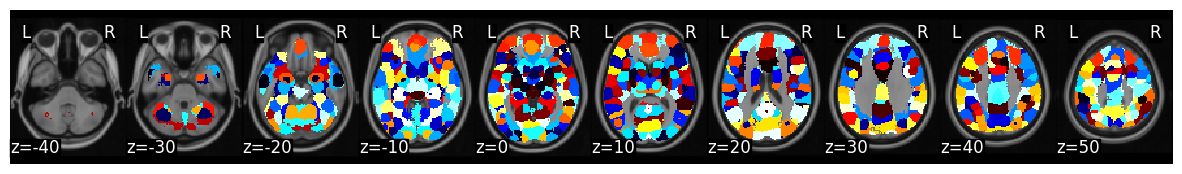

In [4]:
### Mask
maskdir = 'E:\\lxq\\jupyter\\Scripts\\RSA_MVPA\\'
mask = Brain_Data(os.path.join(maskdir,'Neurosynth_Parcellation_2.nii.gz'))
mask.plot()
print(mask)

In [ ]:
### Split the mask
mask_all = expand_mask(mask)
print(type(mask_all))

### Split the mask
mask_all = expand_mask(mask)
print(type(mask_all))

mask_info = glob.glob(os.path.join(maskdir,'mask200_info.csv'))[0]
mask_all.X = pd.read_csv(mask_info)
print(mask_all)

mask_all[116].iplot()

### Behavioral RDM 

In [16]:
subID = data.X['subID'].unique()
subID

array([7001, 7002, 7003, 7004, 7005, 7007, 7008, 7009, 7011, 7012, 7013,
       7014, 7015, 7016, 7017, 7018, 7020, 7022, 7023, 7024, 7025, 7026,
       7027, 7028, 7029, 7030, 7031, 7032, 7033, 7034, 7035, 7036, 7037,
       7038, 7039, 7040, 7041, 7042, 7043, 7044, 7045, 7046, 7047, 7048,
       7049, 7050], dtype=int64)

In [17]:
t_item = 'Cost'

In [18]:
sub7001_data = data[data.X['subID']==7031]
sub7001_bdata = data.X[data.X['subID']==7031]
sub7001_bdata[t_item].values.reshape(-1,1)

# sub7001_bdata_np['Guilt'].reshape(-1, 1)

array([[2],
       [8],
       [5],
       [2],
       [5],
       [8]], dtype=int64)

In [19]:
sub7001_data

nltools.data.brain_data.Brain_Data(data=(6, 238955), Y=(0, 0), X=(6, 14), mask=MNI152_T1_2mm_brain_mask.nii.gz)

array([[0., 6., 3., 0., 3., 6.],
       [6., 0., 3., 6., 3., 0.],
       [3., 3., 0., 3., 0., 3.],
       [0., 6., 3., 0., 3., 6.],
       [3., 3., 0., 3., 0., 3.],
       [6., 0., 3., 6., 3., 0.]])

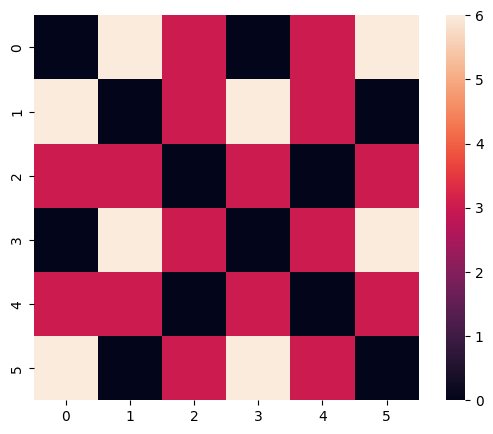

In [20]:
model_dist_1 = Adjacency(pairwise_distances(sub7001_bdata[t_item].values.reshape(-1, 1), metric = 'euclidean'))
model_dist_1.plot()
model_dist_1.squareform()

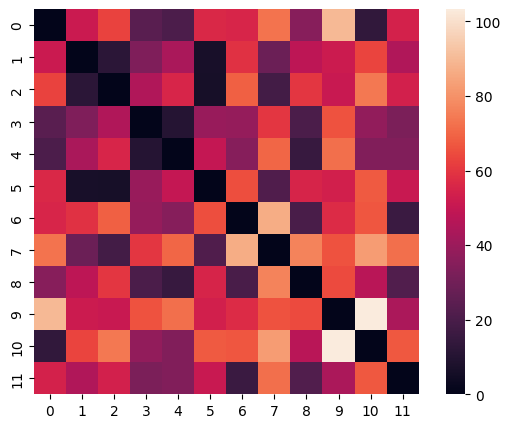

In [18]:
model_dist = Adjacency(pairwise_distances(sub7001_bdata[['Mood','Surprise']], metric = 'euclidean'))
model_dist.plot()

### Conduct RSA 

array([[0.        , 0.55771698, 0.93753346, 0.9289093 , 0.57152252,
        0.47547382],
       [0.55771698, 0.        , 0.52449479, 0.98413091, 0.50661889,
        0.65184392],
       [0.93753346, 0.52449479, 0.        , 0.65518927, 0.45594645,
        0.76607416],
       [0.9289093 , 0.98413091, 0.65518927, 0.        , 0.7527366 ,
        0.77022069],
       [0.57152252, 0.50661889, 0.45594645, 0.7527366 , 0.        ,
        0.50207199],
       [0.47547382, 0.65184392, 0.76607416, 0.77022069, 0.50207199,
        0.        ]])

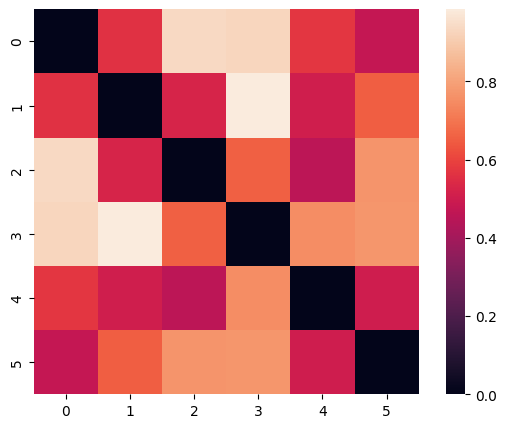

In [21]:
# For one ROI
ROI_mask = mask_all[mask_all.X['Cluster_num']==1]
masked_data  = sub7001_data.apply_mask(ROI_mask)    
ROI_dist = masked_data.distance(metric = 'correlation')
ROI_dist.plot()
ROI_dist.squareform()

# ROI_dist.squareform()

In [22]:
####### all

t_items = ['Cost', 'Intention', 'Allocation', 'Gratitude']

subID = data.X['subID'].unique()
sub_num = len(subID)
roi_num = 200

results_r = np.zeros((roi_num,sub_num))
results_p = np.zeros((roi_num,sub_num))


for t_item in t_items:
    print(t_item)

    for i,sub in enumerate(subID):
        print (t_item, sub)
        sub_data = data[data.X['subID']==sub]
        sub_bdata = data.X[data.X['subID']==sub]
        
        pair_dist = pairwise_distances(sub_bdata[t_item].values.reshape(-1, 1), metric = 'euclidean')
        pair_dist = (pair_dist + pair_dist.T)/2
        
        model_dist = Adjacency(pair_dist)
        
        bar = progressbar.ProgressBar(maxval=roi_num, widgets=[progressbar.Percentage(), ' ', progressbar.Bar(), ' ', progressbar.Timer()])
        
        # Start the progress bar
        bar.start()
        
        for k in mask_all.X['Cluster_num']: 
            # print (t_item, sub, k)
            ROI_mask = mask_all[mask_all.X['Cluster_num']==k]
            masked_data  =  sub_data.apply_mask(ROI_mask)    
            ROI_dist = masked_data.distance(metric = 'correlation')
            Brain_Beha_corr = ROI_dist.similarity(model_dist,plot = False, n_permute = 1, metric='spearman')

            results_r[k-1,i] = Brain_Beha_corr['correlation']
            # results_p[k-1,i] = Brain_Beha_corr['p']  
            
            bar.update(k)
        
        bar.finish()
    results_r_dir = results_dir + 'WSRSA_'+ t_item + '_200_r_value_241106.txt'
    # results_p_dir = results_dir + 'Withinsubject_RSA_'+ t_item + '_200_p_value.txt'

    np.savetxt(results_r_dir,results_r)    
    # np.savetxt(results_p_dir,results_p)  

    print(t_item, ' finished!')
    
# t_items = [  'Certainty', 'Cost', 'Intention', 'Gratitude', 'Allocation'] # 'Reeval',

Cost
Cost 7001


100% |##################################################| Elapsed Time: 0:01:18


Cost 7002


100% |##################################################| Elapsed Time: 0:00:41


Cost 7003


100% |##################################################| Elapsed Time: 0:00:42


Cost 7004


100% |##################################################| Elapsed Time: 0:00:42


Cost 7005


100% |##################################################| Elapsed Time: 0:00:41


Cost 7007


100% |##################################################| Elapsed Time: 0:00:41


Cost 7008


100% |##################################################| Elapsed Time: 0:00:41


Cost 7009


100% |##################################################| Elapsed Time: 0:00:41


Cost 7011


100% |##################################################| Elapsed Time: 0:00:41


Cost 7012


100% |##################################################| Elapsed Time: 0:00:41


Cost 7013


100% |##################################################| Elapsed Time: 0:00:41


Cost 7014


100% |##################################################| Elapsed Time: 0:00:41


Cost 7015


100% |##################################################| Elapsed Time: 0:00:41


Cost 7016


100% |##################################################| Elapsed Time: 0:00:41


Cost 7017


100% |##################################################| Elapsed Time: 0:00:41


Cost 7018


100% |##################################################| Elapsed Time: 0:00:41


Cost 7020


100% |##################################################| Elapsed Time: 0:00:41


Cost 7022


100% |##################################################| Elapsed Time: 0:00:42


Cost 7023


100% |##################################################| Elapsed Time: 0:00:42


Cost 7024


100% |##################################################| Elapsed Time: 0:00:42


Cost 7025


100% |##################################################| Elapsed Time: 0:00:42


Cost 7026


100% |##################################################| Elapsed Time: 0:00:43


Cost 7027


100% |##################################################| Elapsed Time: 0:00:43


Cost 7028


100% |##################################################| Elapsed Time: 0:00:43


Cost 7029


100% |##################################################| Elapsed Time: 0:00:43


Cost 7030


100% |##################################################| Elapsed Time: 0:00:43


Cost 7031


100% |##################################################| Elapsed Time: 0:00:44


Cost 7032


100% |##################################################| Elapsed Time: 0:00:44


Cost 7033


100% |##################################################| Elapsed Time: 0:00:44


Cost 7034


100% |##################################################| Elapsed Time: 0:00:44


Cost 7035


100% |##################################################| Elapsed Time: 0:00:44


Cost 7036


100% |##################################################| Elapsed Time: 0:00:44


Cost 7037


100% |##################################################| Elapsed Time: 0:00:44


Cost 7038


100% |##################################################| Elapsed Time: 0:00:44


Cost 7039


100% |##################################################| Elapsed Time: 0:00:44


Cost 7040


100% |##################################################| Elapsed Time: 0:00:44


Cost 7041


100% |##################################################| Elapsed Time: 0:00:44


Cost 7042


100% |##################################################| Elapsed Time: 0:00:45


Cost 7043


100% |##################################################| Elapsed Time: 0:00:45


Cost 7044


100% |##################################################| Elapsed Time: 0:00:45


Cost 7045


100% |##################################################| Elapsed Time: 0:00:45


Cost 7046


100% |##################################################| Elapsed Time: 0:00:45


Cost 7047


100% |##################################################| Elapsed Time: 0:00:46


Cost 7048


100% |##################################################| Elapsed Time: 0:00:46


Cost 7049


100% |##################################################| Elapsed Time: 0:00:46


Cost 7050


100% |##################################################| Elapsed Time: 0:00:46


Cost  finished!
Intention
Intention 7001


100% |##################################################| Elapsed Time: 0:00:47


Intention 7002


100% |##################################################| Elapsed Time: 0:00:47


Intention 7003


100% |##################################################| Elapsed Time: 0:00:47


Intention 7004


100% |##################################################| Elapsed Time: 0:00:47


Intention 7005


100% |##################################################| Elapsed Time: 0:00:47


Intention 7007


100% |##################################################| Elapsed Time: 0:00:47


Intention 7008


100% |##################################################| Elapsed Time: 0:00:47


Intention 7009


100% |##################################################| Elapsed Time: 0:00:47


Intention 7011


100% |##################################################| Elapsed Time: 0:00:48


Intention 7012


100% |##################################################| Elapsed Time: 0:00:48


Intention 7013


100% |##################################################| Elapsed Time: 0:00:48


Intention 7014


100% |##################################################| Elapsed Time: 0:00:48


Intention 7015


100% |##################################################| Elapsed Time: 0:00:48


Intention 7016


c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
100% |##################################################| Elapsed Time: 0:00:48


Intention 7017


100% |##################################################| Elapsed Time: 0:00:49


Intention 7018


100% |##################################################| Elapsed Time: 0:00:49


Intention 7020


100% |##################################################| Elapsed Time: 0:00:49


Intention 7022


c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
100% |##################################################| Elapsed Time: 0:00:49


Intention 7023


100% |##################################################| Elapsed Time: 0:00:50


Intention 7024


100% |##################################################| Elapsed Time: 0:00:50


Intention 7025


100% |##################################################| Elapsed Time: 0:00:50


Intention 7026


100% |##################################################| Elapsed Time: 0:00:50


Intention 7027


100% |##################################################| Elapsed Time: 0:00:50


Intention 7028


100% |##################################################| Elapsed Time: 0:00:50


Intention 7029


100% |##################################################| Elapsed Time: 0:00:50


Intention 7030


100% |##################################################| Elapsed Time: 0:00:50


Intention 7031


100% |##################################################| Elapsed Time: 0:00:51


Intention 7032


100% |##################################################| Elapsed Time: 0:00:50


Intention 7033


100% |##################################################| Elapsed Time: 0:00:51


Intention 7034


100% |##################################################| Elapsed Time: 0:00:51


Intention 7035


100% |##################################################| Elapsed Time: 0:00:51


Intention 7036


100% |##################################################| Elapsed Time: 0:00:51


Intention 7037


100% |##################################################| Elapsed Time: 0:00:52


Intention 7038


100% |##################################################| Elapsed Time: 0:00:52


Intention 7039


100% |##################################################| Elapsed Time: 0:00:52


Intention 7040


100% |##################################################| Elapsed Time: 0:00:53


Intention 7041


100% |##################################################| Elapsed Time: 0:00:52


Intention 7042


100% |##################################################| Elapsed Time: 0:00:52


Intention 7043


100% |##################################################| Elapsed Time: 0:00:53


Intention 7044


100% |##################################################| Elapsed Time: 0:00:53


Intention 7045


100% |##################################################| Elapsed Time: 0:00:53


Intention 7046


100% |##################################################| Elapsed Time: 0:00:53


Intention 7047


100% |##################################################| Elapsed Time: 0:00:53


Intention 7048


100% |##################################################| Elapsed Time: 0:00:54


Intention 7049


100% |##################################################| Elapsed Time: 0:00:54


Intention 7050


100% |##################################################| Elapsed Time: 0:00:53


Intention  finished!
Allocation
Allocation 7001


100% |##################################################| Elapsed Time: 0:00:53


Allocation 7002


100% |##################################################| Elapsed Time: 0:00:53


Allocation 7003


100% |##################################################| Elapsed Time: 0:00:54


Allocation 7004


100% |##################################################| Elapsed Time: 0:00:54


Allocation 7005


100% |##################################################| Elapsed Time: 0:00:54


Allocation 7007


100% |##################################################| Elapsed Time: 0:00:54


Allocation 7008


100% |##################################################| Elapsed Time: 0:00:55


Allocation 7009


100% |##################################################| Elapsed Time: 0:00:57


Allocation 7011


100% |##################################################| Elapsed Time: 0:00:59


Allocation 7012


100% |##################################################| Elapsed Time: 0:00:58


Allocation 7013


100% |##################################################| Elapsed Time: 0:00:59


Allocation 7014


100% |##################################################| Elapsed Time: 0:00:58


Allocation 7015


100% |##################################################| Elapsed Time: 0:00:59


Allocation 7016


100% |##################################################| Elapsed Time: 0:00:58


Allocation 7017


100% |##################################################| Elapsed Time: 0:01:00


Allocation 7018


100% |##################################################| Elapsed Time: 0:00:59


Allocation 7020


100% |##################################################| Elapsed Time: 0:00:57


Allocation 7022


100% |##################################################| Elapsed Time: 0:00:58


Allocation 7023


100% |##################################################| Elapsed Time: 0:00:58


Allocation 7024


100% |##################################################| Elapsed Time: 0:00:58


Allocation 7025


100% |##################################################| Elapsed Time: 0:00:58


Allocation 7026


100% |##################################################| Elapsed Time: 0:00:59


Allocation 7027


100% |##################################################| Elapsed Time: 0:01:00


Allocation 7028


100% |##################################################| Elapsed Time: 0:01:00


Allocation 7029


100% |##################################################| Elapsed Time: 0:01:00


Allocation 7030


100% |##################################################| Elapsed Time: 0:01:00


Allocation 7031


100% |##################################################| Elapsed Time: 0:01:01


Allocation 7032


100% |##################################################| Elapsed Time: 0:01:00


Allocation 7033


100% |##################################################| Elapsed Time: 0:01:01


Allocation 7034


100% |##################################################| Elapsed Time: 0:01:01


Allocation 7035


100% |##################################################| Elapsed Time: 0:01:01


Allocation 7036


100% |##################################################| Elapsed Time: 0:01:00


Allocation 7037


100% |##################################################| Elapsed Time: 0:01:00


Allocation 7038


100% |##################################################| Elapsed Time: 0:01:02


Allocation 7039


100% |##################################################| Elapsed Time: 0:01:01


Allocation 7040


100% |##################################################| Elapsed Time: 0:01:00


Allocation 7041


100% |##################################################| Elapsed Time: 0:01:02


Allocation 7042


100% |##################################################| Elapsed Time: 0:01:00


Allocation 7043


100% |##################################################| Elapsed Time: 0:01:06


Allocation 7044


100% |##################################################| Elapsed Time: 0:01:05


Allocation 7045


100% |##################################################| Elapsed Time: 0:01:06


Allocation 7046


100% |##################################################| Elapsed Time: 0:01:06


Allocation 7047


100% |##################################################| Elapsed Time: 0:01:07


Allocation 7048


100% |##################################################| Elapsed Time: 0:01:07


Allocation 7049


100% |##################################################| Elapsed Time: 0:01:07


Allocation 7050


100% |##################################################| Elapsed Time: 0:01:06


Allocation  finished!
Gratitude
Gratitude 7001


100% |##################################################| Elapsed Time: 0:01:07


Gratitude 7002


100% |##################################################| Elapsed Time: 0:01:08


Gratitude 7003


100% |##################################################| Elapsed Time: 0:01:09


Gratitude 7004


100% |##################################################| Elapsed Time: 0:01:10


Gratitude 7005


100% |##################################################| Elapsed Time: 0:01:07


Gratitude 7007


100% |##################################################| Elapsed Time: 0:01:05


Gratitude 7008


100% |##################################################| Elapsed Time: 0:01:03


Gratitude 7009


100% |##################################################| Elapsed Time: 0:01:03


Gratitude 7011


100% |##################################################| Elapsed Time: 0:01:03


Gratitude 7012


100% |##################################################| Elapsed Time: 0:01:03


Gratitude 7013


100% |##################################################| Elapsed Time: 0:01:04


Gratitude 7014


100% |##################################################| Elapsed Time: 0:01:04


Gratitude 7015


100% |##################################################| Elapsed Time: 0:01:04


Gratitude 7016


100% |##################################################| Elapsed Time: 0:01:04


Gratitude 7017


100% |##################################################| Elapsed Time: 0:01:04


Gratitude 7018


100% |##################################################| Elapsed Time: 0:01:05


Gratitude 7020


100% |##################################################| Elapsed Time: 0:01:05


Gratitude 7022


c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
100% |##################################################| Elapsed Time: 0:01:05


Gratitude 7023


100% |##################################################| Elapsed Time: 0:01:05


Gratitude 7024


100% |##################################################| Elapsed Time: 0:01:05


Gratitude 7025


100% |##################################################| Elapsed Time: 0:01:05


Gratitude 7026


100% |##################################################| Elapsed Time: 0:01:06


Gratitude 7027


100% |##################################################| Elapsed Time: 0:01:06


Gratitude 7028


100% |##################################################| Elapsed Time: 0:01:06


Gratitude 7029


100% |##################################################| Elapsed Time: 0:01:06


Gratitude 7030


100% |##################################################| Elapsed Time: 0:01:06


Gratitude 7031


100% |##################################################| Elapsed Time: 0:01:06


Gratitude 7032


100% |##################################################| Elapsed Time: 0:01:06


Gratitude 7033


100% |##################################################| Elapsed Time: 0:01:07


Gratitude 7034


100% |##################################################| Elapsed Time: 0:01:07


Gratitude 7035


100% |##################################################| Elapsed Time: 0:01:07


Gratitude 7036


100% |##################################################| Elapsed Time: 0:01:07


Gratitude 7037


100% |##################################################| Elapsed Time: 0:01:07


Gratitude 7038


100% |##################################################| Elapsed Time: 0:01:07


Gratitude 7039


100% |##################################################| Elapsed Time: 0:01:08


Gratitude 7040


100% |##################################################| Elapsed Time: 0:01:08


Gratitude 7041


100% |##################################################| Elapsed Time: 0:01:08


Gratitude 7042


100% |##################################################| Elapsed Time: 0:01:08


Gratitude 7043


100% |##################################################| Elapsed Time: 0:01:09


Gratitude 7044


100% |##################################################| Elapsed Time: 0:01:09


Gratitude 7045


100% |##################################################| Elapsed Time: 0:01:09


Gratitude 7046


100% |##################################################| Elapsed Time: 0:01:09


Gratitude 7047


100% |##################################################| Elapsed Time: 0:01:09


Gratitude 7048


100% |##################################################| Elapsed Time: 0:01:09


Gratitude 7049


100% |##################################################| Elapsed Time: 0:01:09


Gratitude 7050


Gratitude  finished!


In [142]:
np.savetxt(os.path.join(results_dir,'Withinsubject_RSA_Gratitude_200_r_value.txt'),results_r)    
# np.savetxt(os.path.join(results_dir,'Withinsubject_RSA_Intention_200_p_value.txt'),results_p)  

In [143]:
results_r = np.loadtxt(os.path.join(results_dir,'Withinsubject_RSA_Intention_200_r_value.txt'),delimiter = ' ', skiprows = 0)
# results_p = np.loadtxt(os.path.join(results_dir,'Withinsubject_RSA_Intention_200_p_value.txt'),delimiter = ' ', skiprows = 0)

###  Significance test

In [20]:
from nltools.stats import fdr, threshold, fisher_r_to_z, one_sample_permutation

nltools.data.brain_data.Brain_Data(data=(238955,), Y=(0, 0), X=(0, 0), mask=MNI152_T1_2mm_brain_mask.nii.gz)
<class 'nltools.data.brain_data.Brain_Data'>
nltools.data.brain_data.Brain_Data(data=(200, 238955), Y=(0, 0), X=(200, 1), mask=MNI152_T1_2mm_brain_mask.nii.gz)


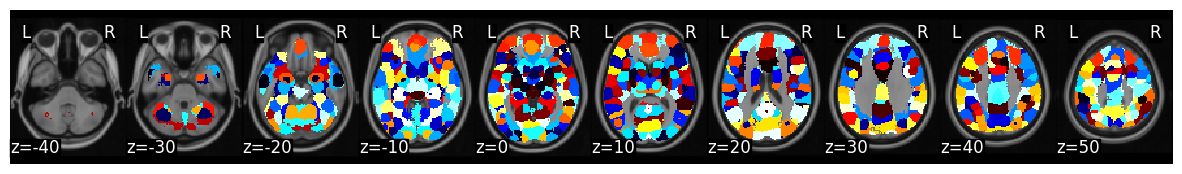

In [23]:
### Mask
maskdir = 'E:\\lxq\\jupyter\\Scripts\\RSA_MVPA\\'
mask = Brain_Data(os.path.join(maskdir,'Neurosynth_Parcellation_2.nii.gz'))
mask.plot()
print(mask)

### Split the mask
mask_all = expand_mask(mask)
print(type(mask_all))

mask_info = glob.glob(os.path.join(maskdir,'mask200_info.csv'))[0]
mask_all.X = pd.read_csv(mask_info)
print(mask_all)

c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\numpy\core\fromnumeric.py:758: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\nilearn\image\resampling.py:756: UserWarning: Casting data from int32 to float32
  return resample_img(
c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\nilearn\image\resampling.py:293: UserWarning: Resampling binary images with continuous or linear interpolation. This might lead to unexpected results. You might consider using nearest interpolation instead.
  warnings.warn(



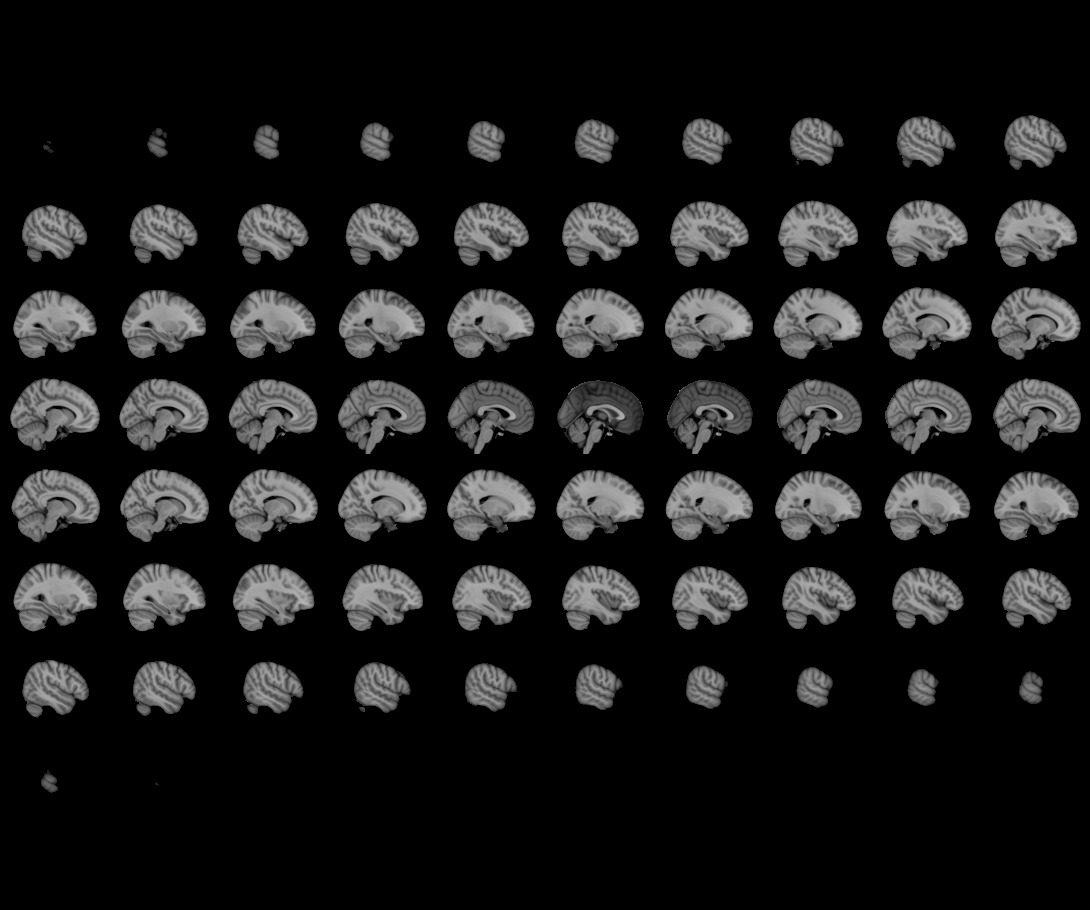
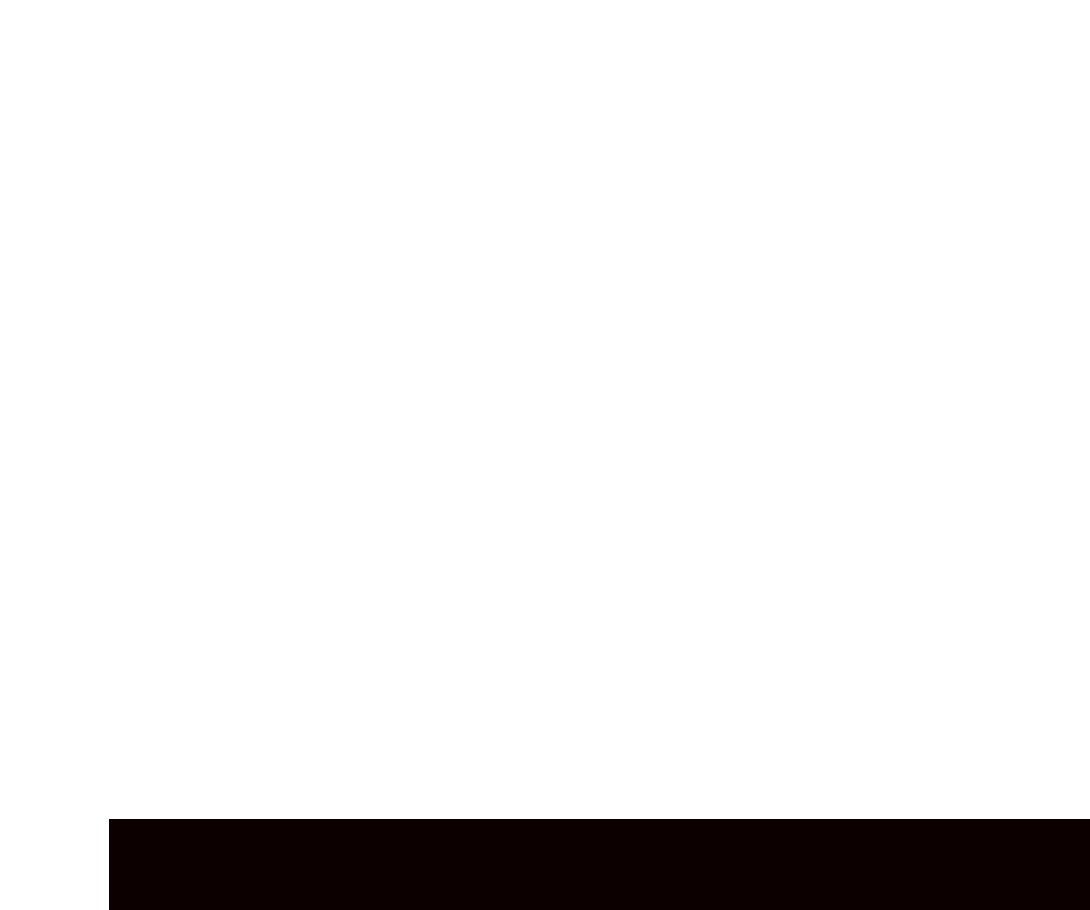

interactive(children=(FloatText(value=0.0, description='Threshold'), HTML(value='Image is 3D', description='Vo…

In [27]:
mask_all[142].iplot()

c:\users\cbcs\appdata\local\programs\python\python38\lib\site-packages\numpy\core\fromnumeric.py:758: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



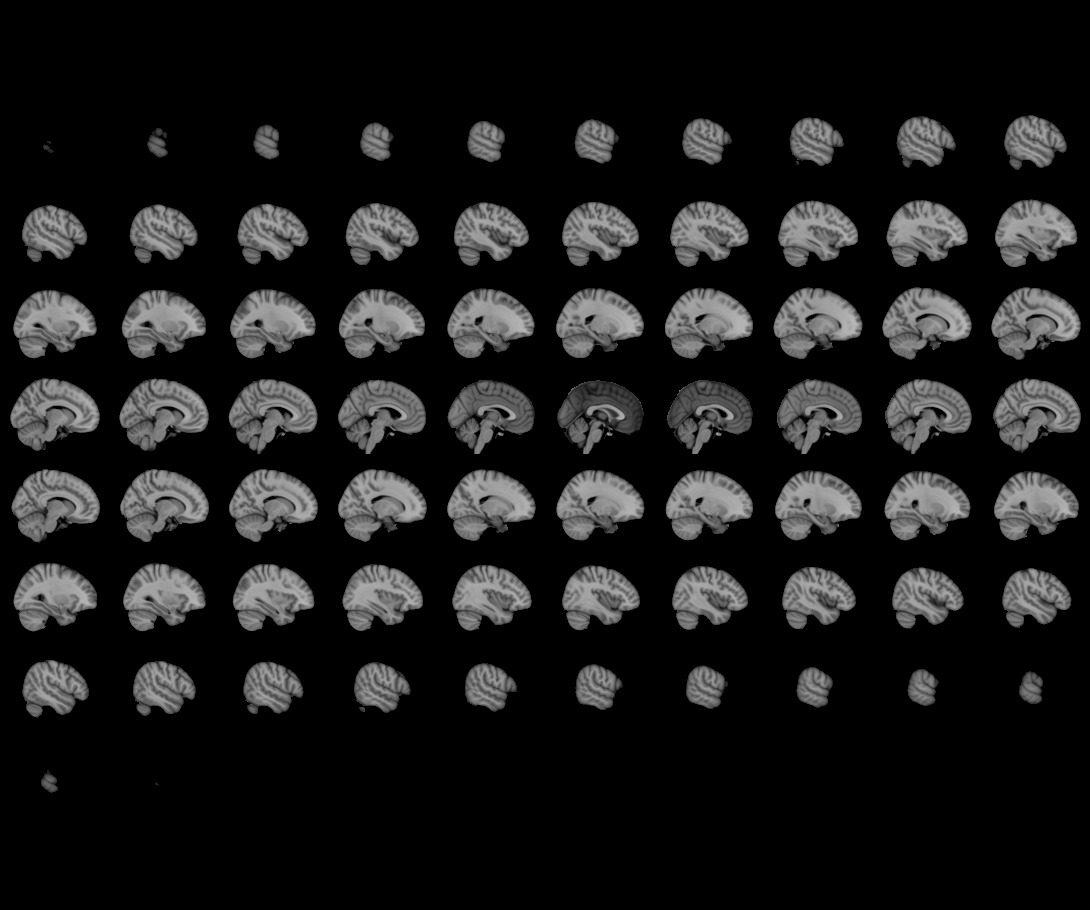
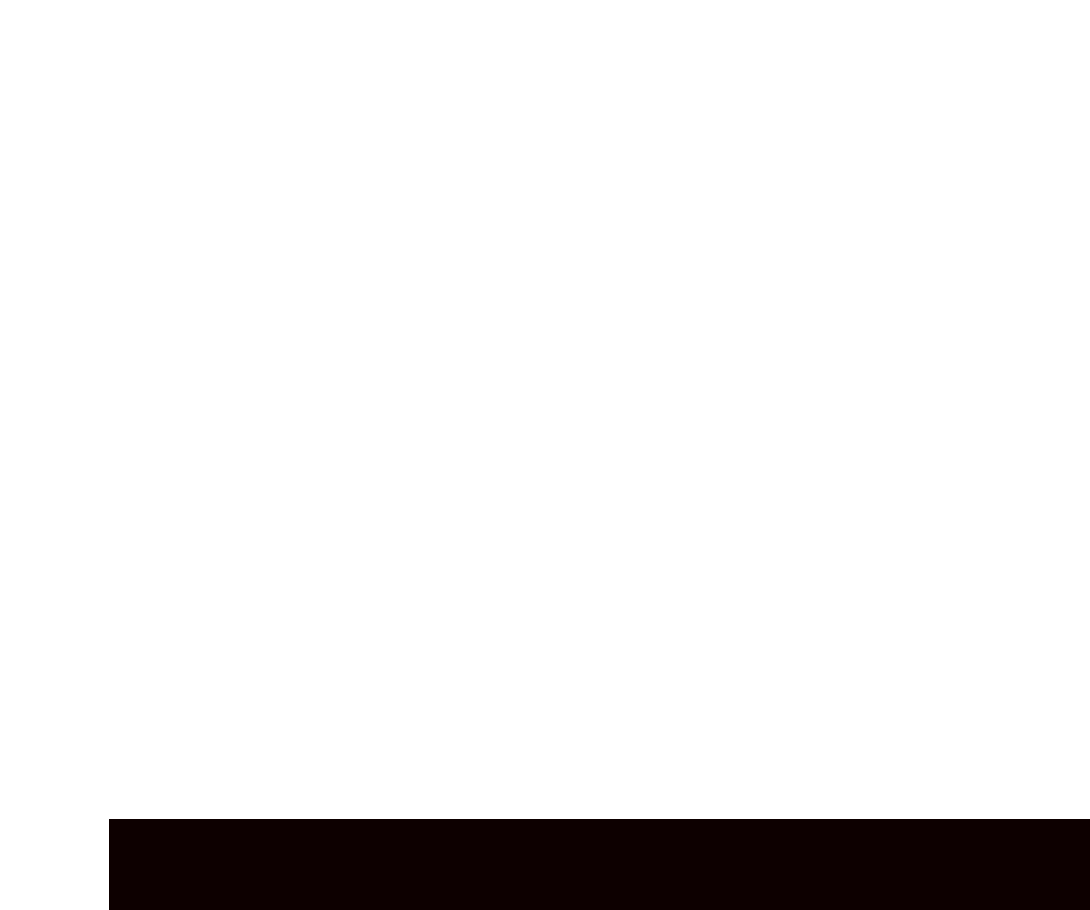

interactive(children=(FloatText(value=0.0, description='Threshold'), HTML(value='Image is 3D', description='Vo…

In [25]:
### bf permutation 100000
threshold_list = []
rsa_p_list = []

t_items = ['Cost', 'Intention', 'Allocation', 'Gratitude'] 

for t_item in t_items:
    rsa_stats = []

    results_r_dir = results_dir + 'WSRSA_'+ t_item + '_200_r_value_241106.txt'
    # results_p_dir = results_dir + 'Withinsubject_RSA_'+ t_item + '_200_p_value.txt'
    
    results_r = np.loadtxt(results_r_dir,delimiter = ' ', skiprows = 0)
    # results_p = np.loadtxt(results_p_dir,delimiter = ' ', skiprows = 0)

    for k in mask_all.X['Cluster_num']:
        roi_r = np.array(fisher_r_to_z(results_r[k-1,:]))
        roi_r_no_nan = roi_r[~np.isnan(roi_r)]
        rsa_stats.append(one_sample_permutation(roi_r_no_nan, n_permute=100000))

    rsa_p_list.append(rsa_stats)
    
    # 将字典写入CSV文件
    csv_file_path = results_dir + t_item + '_r_p_100000_241106.csv'
    
    # 将列表转换为 DataFrame
    rsa_stats_df = pd.DataFrame(rsa_stats, columns=["mean", "p"])
    
    rsa_stats_df.to_csv(csv_file_path, index = False)
    
    count = sum(1 for x in rsa_stats if x['p'] <= 0.00025)
    print(t_item, count, " (sig)")

    rsa_r = Brain_Data([x*y['mean'] for x,y in zip(mask_all, rsa_stats)]).sum()
    rsa_p = Brain_Data([x*y['p'] for x,y in zip(mask_all, rsa_stats)]).sum()

    thresholded = threshold(rsa_r, rsa_p, thr=0.00025)

    plot_glass_brain(thresholded.to_nifti(), cmap='coolwarm')

    thresholded.write(os.path.join(results_dir,str('WSRSA_' + t_item + '_200_bf_100000_241106.nii.gz')))

    thresholded.iplot()
    
    threshold_list.append(thresholded)

In [22]:
results_1011_dir = 'E:\\lxq\\jupyter\\CMF2024\\fmri\\03_rsa\\20241011_rsa_6Onset_gratitude\\WSRSA_condition_results_20241011_6Onset\\'

results_1011_r = np.loadtxt(os.path.join(results_1011_dir,'Withinsubject_RSA_Gratitude_200_r_value.txt'),delimiter = ' ', skiprows = 0)
print(results_1011_r[147])

print(one_sample_permutation(np.array(fisher_r_to_z(results_1011_r[147,:])),n_permute=100000))

[-0.26165043 -0.11428571 -0.01431129  0.11957778  0.15426164 -0.04834395
 -0.17749928  0.36428571 -0.11071429 -0.323793   -0.08928571  0.25357143
 -0.36282409 -0.29848091 -0.18571429  0.06522424 -0.22003613         nan
 -0.21288048 -0.17531334  0.05129892  0.48300614 -0.30357143  0.17710225
 -0.04114497 -0.25357143 -0.15549604 -0.03623569 -0.30126368 -0.07513429
  0.675      -0.27289444  0.11111182  0.1823057   0.31315103  0.12701273
  0.375       0.37097012 -0.13799372  0.17531334 -0.24193704  0.00714286
 -0.14145082 -0.19481688 -0.11627926 -0.01785714]
{'mean': -0.01583411553472717, 'p': 9.99990000099999e-06}


In [20]:
results_0505_dir = 'E:\\lxq\\jupyter\\CMF2024\\fmri\\03_rsa\\20240505_rsa_6onset\\WSRSA_condition_results_20240505_6Onset\\'

results_0505_r = np.loadtxt(os.path.join(results_0505_dir,'Withinsubject_RSA_Gratitude_200_r_value.txt'),delimiter = ' ', skiprows = 0)
print(results_0505_r[147])

print(one_sample_permutation(np.array(fisher_r_to_z(results_0505_r[147,:])),n_permute=100000))

[ 0.28573718 -0.35357143  0.35007953  0.01449428  0.03049358  0.184589
  0.29991257  0.02142857 -0.18571429  0.55357143 -0.11270143 -0.28596973
 -0.23592503  0.00357462  0.36071429  0.36960404  0.16653118         nan
 -0.18508902  0.1699466   0.5239818   0.46732487 -0.19678028 -0.3381043
 -0.35484099  0.49687241  0.01071429  0.29780538  0.01496962  0.25357143
  0.03225827 -0.00358103  0.53488458 -0.25494086  0.33306236 -0.06983015
  0.08928571 -0.06093229  0.35304886  0.67799751 -0.3351276   0.79785459
  0.42142857 -0.21090268 -0.2772813   0.33214286]
{'mean': 0.12820838525645495, 'p': 9.99990000099999e-06}


In [35]:
results_1013_dir = 'E:\\lxq\\jupyter\\CMF2024\\fmri\\03_rsa\\20241011_rsa_6Onset_gratitude\\WSRSA_condition_results_20241011_6Onset\\'

results_1013_r = np.loadtxt(os.path.join(results_1013_dir,'Withinsubject_RSA_Gratitude_roi148_r_value_241013_final.txt'),delimiter = ' ', skiprows = 0)
print(results_1013_r[147])

print(one_sample_permutation(np.array(fisher_r_to_z(results_1013_r[147,:])),n_permute=100000))

[ 0.28573718 -0.36428571  0.2611811   0.01449428  0.03049358  0.184589
  0.29991257  0.02142857 -0.08214286  0.55357143 -0.12142857 -0.10357143
 -0.23592503  0.00357462  0.36071429  0.36960404  0.16653118         nan
 -0.18508902  0.1699466   0.5239818   0.64043036 -0.19678028 -0.3381043
 -0.24150307  0.49687241  0.01071429  0.29780538  0.01496962  0.25357143
  0.20714286 -0.00358103  0.58423314 -0.27703318  0.33306236 -0.13595728
  0.21785714 -0.06093229  0.35304886  0.67799751 -0.3351276   0.79785459
  0.42142857 -0.21090268 -0.2772813   0.33214286]
{'mean': 0.14697311571669364, 'p': 9.99990000099999e-06}


In [31]:
results_1013_dir = 'E:\\lxq\\jupyter\\CMF2024\\fmri\\03_rsa\\20241011_rsa_6Onset_gratitude\\WSRSA_condition_results_20241011_6Onset\\'

results_1013_r = np.loadtxt(os.path.join(results_1013_dir,'Withinsubject_RSA_Gratitude_roi148_r_value_241013.txt'),delimiter = ' ', skiprows = 0)
print(results_1013_r[147])

print(one_sample_permutation(np.array(fisher_r_to_z(results_1013_r[147,:])),n_permute=100000))

[ 0.3279591  -0.36428571  0.32737083  0.01449428  0.03049358  0.0644586
  0.29991257  0.02142857 -0.08214286  0.64221927 -0.12142857 -0.10357143
 -0.23592503  0.00357462  0.18214286  0.36960404  0.28801477         nan
 -0.24150307  0.1699466   0.5239818   0.64043036  0.33928571 -0.3381043
 -0.24150307  0.16428571  0.01966042  0.10870707  0.01496962  0.15205749
  0.20714286  0.0215443   0.58423314 -0.27703318  0.33306236 -0.13595728
  0.21785714 -0.06093229  0.35304886  0.67799751 -0.3351276   0.54642857
  0.29543526 -0.21090268 -0.2772813   0.33214286]
{'mean': 0.1311987912044987, 'p': 9.99990000099999e-06}


In [23]:
for i in range(len(results_0505_r[147])):
    print(subID[i], results_0505_r[147][i], results_1013_r[147][i], results_1011_r[147][i]) 

7001 0.28573717857003444 0.3279590958501892 -0.26165042619741874
7002 -0.35357142857142854 -0.36428571428571427 -0.11428571428571425
7003 0.3500795284830299 0.3273708279400825 -0.01431129302470306
7004 0.01449427589131121 0.01449427589131121 0.11957777610331749
7005 0.03049358014170244 0.03049358014170244 0.15426164071684767
7007 0.18458899930365838 0.06445860311683207 -0.048343952337624056
7008 0.29991257467394133 0.29991257467394133 -0.17749927888865913
7009 0.021428571428571425 0.021428571428571425 0.36428571428571427
7011 -0.1857142857142857 -0.08214285714285713 -0.11071428571428568
7012 0.5535714285714285 0.6422192744835499 -0.3237930046839067
7013 -0.11270143256953662 -0.12142857142857141 -0.08928571428571427
7014 -0.2859697299188311 -0.10357142857142855 0.25357142857142856
7015 -0.23592502718303568 -0.23592502718303568 -0.36282409483451694
7016 0.0035746216239853886 0.0035746216239853886 -0.2984809056027799
7017 0.3607142857142856 0.18214285714285713 -0.1857142857142857
7018 0.3

## Formal Use

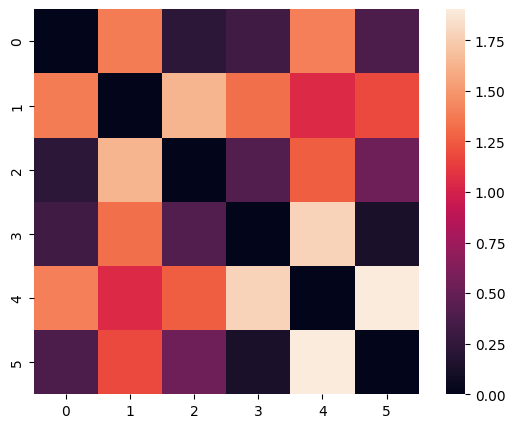

In [18]:
# For one ROI
ROI_mask = mask_all[mask_all.X['Cluster_num']==1]
masked_data  = sub7001_data.apply_mask(ROI_mask)    
ROI_dist = masked_data.distance(metric = 'correlation')
ROI_dist.plot()

In [20]:
print(mask_all.X['Cluster_num'])

0        1
1        2
2        3
3        4
4        5
      ... 
195    196
196    197
197    198
198    199
199    200
Name: Cluster_num, Length: 200, dtype: int64


In [28]:
# print(sub7001_bdata[t_item])
# print(ROI_dist.squareform())
# ROI_dist.plot()
print(len(model_dist.squareform()))
print(masked_data.data)

12
[[ 0.9595054   2.4449654   3.3287268  ...  5.4048676   4.5955715
   3.8761845 ]
 [ 1.0325725   1.6355785   1.1496806  ... -1.014704    0.0193834
  -1.6423075 ]
 [ 0.51909673  2.8600595   4.727964   ...  1.7114731   1.1990632
   0.8450667 ]
 ...
 [-2.3786125  -0.519389    0.02645831 ... -0.22826993  0.24137563
   0.16394904]
 [ 1.9160557   2.8952267   3.1325855  ...  2.3328123   1.893187
   1.7935088 ]
 [ 0.37021866  1.5298498   1.2032344  ...  4.1236167   3.58987
   3.1461308 ]]


Reeval
Reeval 7001
Reeval 7001 1
Reeval 7001 2
Reeval 7001 3
Reeval 7001 4
Reeval 7001 5
Reeval 7001 6
Reeval 7001 7
Reeval 7001 8
Reeval 7001 9
Reeval 7001 10
Reeval 7001 11
Reeval 7001 12
Reeval 7001 13
Reeval 7001 14
Reeval 7001 15
Reeval 7001 16
Reeval 7001 17
Reeval 7001 18
Reeval 7001 19
Reeval 7001 20
Reeval 7001 21
Reeval 7001 22
Reeval 7001 23
Reeval 7001 24
Reeval 7001 25
Reeval 7001 26
Reeval 7001 27
Reeval 7001 28
Reeval 7001 29
Reeval 7001 30
Reeval 7001 31
Reeval 7001 32
Reeval 7001 33
Reeval 7001 34
Reeval 7001 35
Reeval 7001 36
Reeval 7001 37
Reeval 7001 38
Reeval 7001 39
Reeval 7001 40
Reeval 7001 41
Reeval 7001 42
Reeval 7001 43
Reeval 7001 44
Reeval 7001 45
Reeval 7001 46
Reeval 7001 47
Reeval 7001 48
Reeval 7001 49
Reeval 7001 50
Reeval 7001 51
Reeval 7001 52
Reeval 7001 53
Reeval 7001 54
Reeval 7001 55
Reeval 7001 56
Reeval 7001 57
Reeval 7001 58
Reeval 7001 59
Reeval 7001 60
Reeval 7001 61
Reeval 7001 62
Reeval 7001 63
Reeval 7001 64
Reeval 7001 65
Reeval 7001 66


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 2


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 3


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 4


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 5


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 6


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 7


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 8


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 9


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 10


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 11


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 12


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 13


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 14


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 15


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 16


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 17


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 18


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 19


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 20


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 21


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 22


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 23


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 24


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 25


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 26


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 27


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 28


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 29


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 30


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 31


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 32


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 33


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 34


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 35


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 36


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 37


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 38


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 39


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 40


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 41


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 42


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 43


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 44


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 45


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 46


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 47


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 48


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 49


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 50


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 51


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 52


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 53


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 54


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 55


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 56


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 57


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 58


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 59


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 60


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 61


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 62


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 63


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 64


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 65


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 66


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 67


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 68


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 69


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 70


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 71


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 72


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 73


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 74


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 75


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 76


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 77


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 78


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 79


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 80


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 81


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 82


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 83


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 84


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 85


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 86


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 87


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 88


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 89


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 90


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 91


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 92


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 93


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 94


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 95


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 96


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 97


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 98


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 99


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 100


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 101


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 102


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 103


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 104


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 105


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 106


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 107


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 108


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 109


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 110


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 111


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 112


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 113


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 114


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 115


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 116


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 117


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 118


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 119


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 120


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 121


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 122


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 123


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 124


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 125


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 126


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 127


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 128


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 129


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 130


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 131


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 132


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 133


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 134


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 135


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 136


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 137


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 138


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 139


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 140


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 141


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 142


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 143


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 144


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 145


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 146


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 147


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 148


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 149


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 150


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 151


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 152


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 153


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 154


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 155


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 156


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 157


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 158


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 159


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 160


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 161


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 162


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 163


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 164


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 165


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 166


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 167


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 168


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 169


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 170


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 171


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 172


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 173


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 174


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 175


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 176


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 177


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 178


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 179


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 180


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 181


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 182


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 183


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 184


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 185


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 186


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 187


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 188


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 189


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 190


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 191


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 192


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 193


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 194


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 195


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 196


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 197


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 198


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 199


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7022 200


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Intention 7023
Intention 7023 1
Intention 7023 2
Intention 7023 3
Intention 7023 4
Intention 7023 5
Intention 7023 6
Intention 7023 7
Intention 7023 8
Intention 7023 9
Intention 7023 10
Intention 7023 11
Intention 7023 12
Intention 7023 13
Intention 7023 14
Intention 7023 15
Intention 7023 16
Intention 7023 17
Intention 7023 18
Intention 7023 19
Intention 7023 20
Intention 7023 21
Intention 7023 22
Intention 7023 23
Intention 7023 24
Intention 7023 25
Intention 7023 26
Intention 7023 27
Intention 7023 28
Intention 7023 29
Intention 7023 30
Intention 7023 31
Intention 7023 32
Intention 7023 33
Intention 7023 34
Intention 7023 35
Intention 7023 36
Intention 7023 37
Intention 7023 38
Intention 7023 39
Intention 7023 40
Intention 7023 41
Intention 7023 42
Intention 7023 43
Intention 7023 44
Intention 7023 45
Intention 7023 46
Intention 7023 47
Intention 7023 48
Intention 7023 49
Intention 7023 50
Intention 7023 51
Intention 7023 52
Intention 7023 53
Intention 7023 54
Intention 7023 55
Inte

C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 2


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 3


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 4


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 5


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 6


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 7


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 8


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 9


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 10


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 11


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 12


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 13


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 14


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 15


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 16


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 17


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 18


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 19


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 20


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 21


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 22


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 23


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 24


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 25


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 26


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 27


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 28


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 29


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 30


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 31


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 32


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 33


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 34


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 35


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 36


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 37


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 38


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 39


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 40


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 41


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 42


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 43


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 44


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 45


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 46


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 47


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 48


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 49


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 50


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 51


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 52


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 53


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 54


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 55


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 56


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 57


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 58


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 59


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 60


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 61


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 62


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 63


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 64


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 65


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 66


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 67


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 68


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 69


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 70


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 71


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 72


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 73


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 74


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 75


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 76


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 77


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 78


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 79


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 80


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 81


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 82


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 83


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 84


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 85


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 86


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 87


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 88


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 89


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 90


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 91


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 92


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 93


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 94


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 95


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 96


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 97


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 98


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 99


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 100


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 101


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 102


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 103


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 104


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 105


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 106


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 107


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 108


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 109


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 110


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 111


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 112


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 113


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 114


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 115


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 116


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 117


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 118


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 119


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 120


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 121


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 122


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 123


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 124


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 125


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 126


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 127


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 128


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 129


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 130


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 131


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 132


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 133


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 134


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 135


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 136


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 137


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 138


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 139


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 140


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 141


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 142


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 143


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 144


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 145


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 146


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 147


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 148


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 149


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 150


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 151


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 152


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 153


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 154


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 155


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 156


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 157


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 158


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 159


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 160


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 161


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 162


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 163


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 164


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 165


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 166


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 167


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 168


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 169


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 170


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 171


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 172


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 173


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 174


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 175


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 176


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 177


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 178


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 179


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 180


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 181


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 182


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 183


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 184


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 185


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 186


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 187


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 188


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 189


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 190


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 191


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 192


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 193


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 194


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 195


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 196


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 197


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 198


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 199


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 200


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7023
Surprise 7023 1
Surprise 7023 2
Surprise 7023 3
Surprise 7023 4
Surprise 7023 5
Surprise 7023 6
Surprise 7023 7
Surprise 7023 8
Surprise 7023 9
Surprise 7023 10
Surprise 7023 11
Surprise 7023 12
Surprise 7023 13
Surprise 7023 14
Surprise 7023 15
Surprise 7023 16
Surprise 7023 17
Surprise 7023 18
Surprise 7023 19
Surprise 7023 20
Surprise 7023 21
Surprise 7023 22
Surprise 7023 23
Surprise 7023 24
Surprise 7023 25
Surprise 7023 26
Surprise 7023 27
Surprise 7023 28
Surprise 7023 29
Surprise 7023 30
Surprise 7023 31
Surprise 7023 32
Surprise 7023 33
Surprise 7023 34
Surprise 7023 35
Surprise 7023 36
Surprise 7023 37
Surprise 7023 38
Surprise 7023 39
Surprise 7023 40
Surprise 7023 41
Surprise 7023 42
Surprise 7023 43
Surprise 7023 44
Surprise 7023 45
Surprise 7023 46
Surprise 7023 47
Surprise 7023 48
Surprise 7023 49
Surprise 7023 50
Surprise 7023 51
Surprise 7023 52
Surprise 7023 53
Surprise 7023 54
Surprise 7023 55
Surprise 7023 56
Surprise 7023 57
Surprise 7023 58
Surprise 

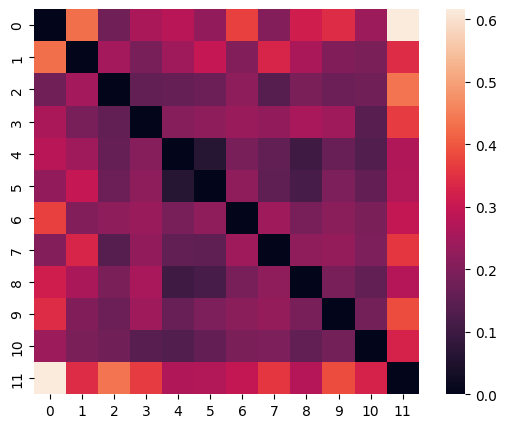

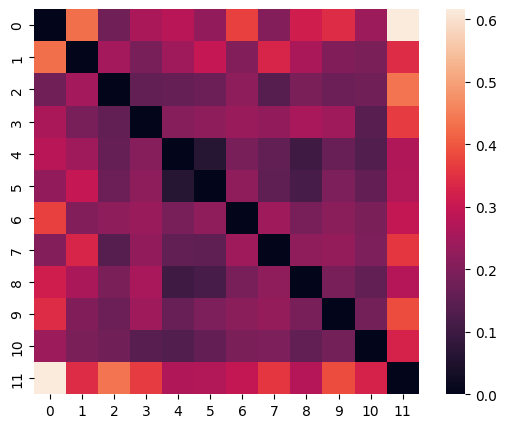

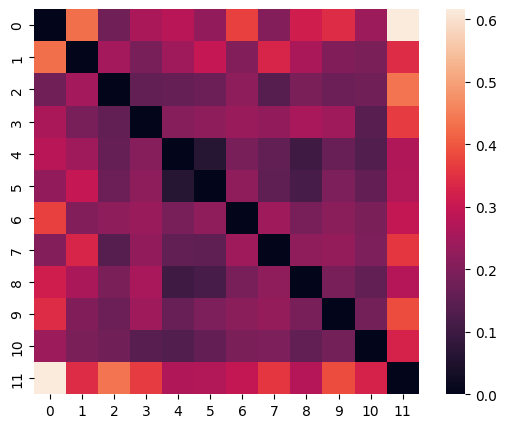

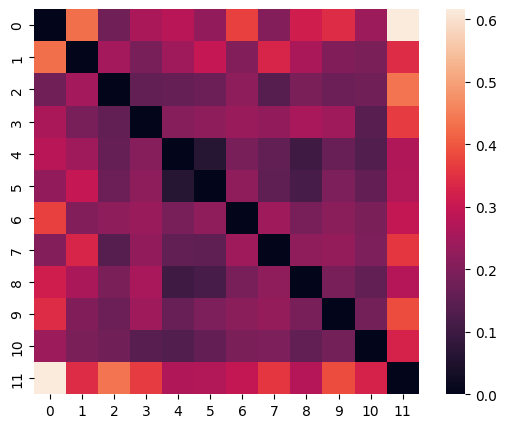

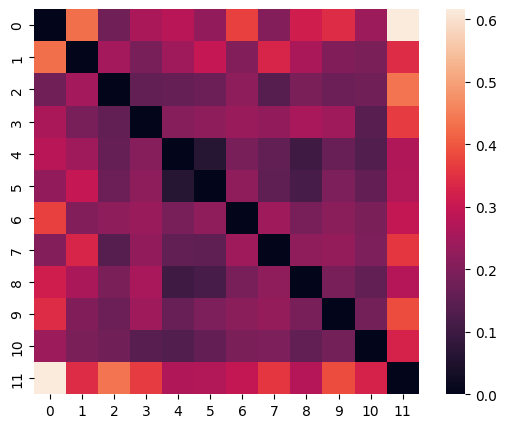

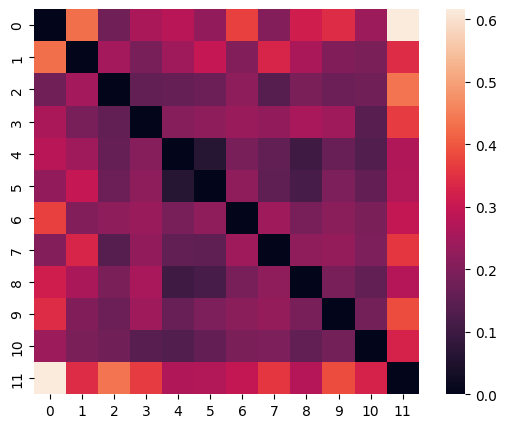

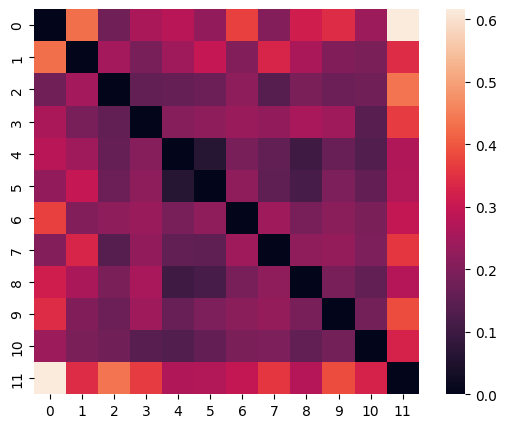

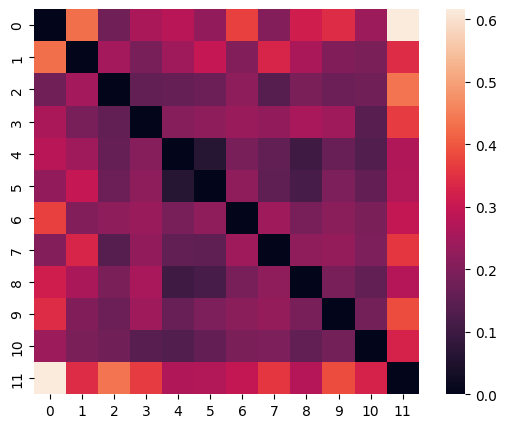

C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 138


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 139


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 140


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 141


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 142


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 143


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 144


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 145


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 146


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 147


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 148


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 149


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 150


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 151


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 152


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 153


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 154


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 155


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 156


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 157


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 158


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 159


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 160


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 161


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 162


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 163


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 164


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 165


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 166


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 167


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 168


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 169


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 170


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 171


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 172


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 173


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 174


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 175


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 176


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 177


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 178


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 179


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 180


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 181


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 182


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 183


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 184


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 185


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 186


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 187


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 188


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 189


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 190


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 191


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 192


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 193


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 194


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 195


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 196


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 197


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 198


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 199


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7022 200


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Surprise 7023
Surprise 7023 1
Surprise 7023 2
Surprise 7023 3
Surprise 7023 4
Surprise 7023 5
Surprise 7023 6
Surprise 7023 7
Surprise 7023 8
Surprise 7023 9
Surprise 7023 10
Surprise 7023 11
Surprise 7023 12
Surprise 7023 13
Surprise 7023 14
Surprise 7023 15
Surprise 7023 16
Surprise 7023 17
Surprise 7023 18
Surprise 7023 19
Surprise 7023 20
Surprise 7023 21
Surprise 7023 22
Surprise 7023 23
Surprise 7023 24
Surprise 7023 25
Surprise 7023 26
Surprise 7023 27
Surprise 7023 28
Surprise 7023 29
Surprise 7023 30
Surprise 7023 31
Surprise 7023 32
Surprise 7023 33
Surprise 7023 34
Surprise 7023 35
Surprise 7023 36
Surprise 7023 37
Surprise 7023 38
Surprise 7023 39
Surprise 7023 40
Surprise 7023 41
Surprise 7023 42
Surprise 7023 43
Surprise 7023 44
Surprise 7023 45
Surprise 7023 46
Surprise 7023 47
Surprise 7023 48
Surprise 7023 49
Surprise 7023 50
Surprise 7023 51
Surprise 7023 52
Surprise 7023 53
Surprise 7023 54
Surprise 7023 55
Surprise 7023 56
Surprise 7023 57
Surprise 7023 58
Surprise 

Surprise 7025 71
Surprise 7025 72
Surprise 7025 73
Surprise 7025 74
Surprise 7025 75
Surprise 7025 76
Surprise 7025 77
Surprise 7025 78
Surprise 7025 79
Surprise 7025 80
Surprise 7025 81
Surprise 7025 82
Surprise 7025 83
Surprise 7025 84
Surprise 7025 85
Surprise 7025 86
Surprise 7025 87
Surprise 7025 88
Surprise 7025 89
Surprise 7025 90
Surprise 7025 91
Surprise 7025 92
Surprise 7025 93
Surprise 7025 94
Surprise 7025 95
Surprise 7025 96
Surprise 7025 97
Surprise 7025 98
Surprise 7025 99
Surprise 7025 100
Surprise 7025 101
Surprise 7025 102
Surprise 7025 103
Surprise 7025 104
Surprise 7025 105
Surprise 7025 106
Surprise 7025 107
Surprise 7025 108
Surprise 7025 109
Surprise 7025 110
Surprise 7025 111
Surprise 7025 112
Surprise 7025 113
Surprise 7025 114
Surprise 7025 115
Surprise 7025 116
Surprise 7025 117
Surprise 7025 118
Surprise 7025 119
Surprise 7025 120
Surprise 7025 121
Surprise 7025 122
Surprise 7025 123
Surprise 7025 124
Surprise 7025 125
Surprise 7025 126
Surprise 7025 127
Sur

Surprise 7027 139
Surprise 7027 140
Surprise 7027 141
Surprise 7027 142
Surprise 7027 143
Surprise 7027 144
Surprise 7027 145
Surprise 7027 146
Surprise 7027 147
Surprise 7027 148
Surprise 7027 149
Surprise 7027 150
Surprise 7027 151
Surprise 7027 152
Surprise 7027 153
Surprise 7027 154
Surprise 7027 155
Surprise 7027 156
Surprise 7027 157
Surprise 7027 158
Surprise 7027 159
Surprise 7027 160
Surprise 7027 161
Surprise 7027 162
Surprise 7027 163
Surprise 7027 164
Surprise 7027 165
Surprise 7027 166
Surprise 7027 167
Surprise 7027 168
Surprise 7027 169
Surprise 7027 170
Surprise 7027 171
Surprise 7027 172
Surprise 7027 173
Surprise 7027 174
Surprise 7027 175
Surprise 7027 176
Surprise 7027 177
Surprise 7027 178
Surprise 7027 179
Surprise 7027 180
Surprise 7027 181
Surprise 7027 182
Surprise 7027 183
Surprise 7027 184
Surprise 7027 185
Surprise 7027 186
Surprise 7027 187
Surprise 7027 188
Surprise 7027 189
Surprise 7027 190
Surprise 7027 191
Surprise 7027 192
Surprise 7027 193
Surprise 7

Surprise 7030 5
Surprise 7030 6
Surprise 7030 7
Surprise 7030 8
Surprise 7030 9
Surprise 7030 10
Surprise 7030 11
Surprise 7030 12
Surprise 7030 13
Surprise 7030 14
Surprise 7030 15
Surprise 7030 16
Surprise 7030 17
Surprise 7030 18
Surprise 7030 19
Surprise 7030 20
Surprise 7030 21
Surprise 7030 22
Surprise 7030 23
Surprise 7030 24
Surprise 7030 25
Surprise 7030 26
Surprise 7030 27
Surprise 7030 28
Surprise 7030 29
Surprise 7030 30
Surprise 7030 31
Surprise 7030 32
Surprise 7030 33
Surprise 7030 34
Surprise 7030 35
Surprise 7030 36
Surprise 7030 37
Surprise 7030 38
Surprise 7030 39
Surprise 7030 40
Surprise 7030 41
Surprise 7030 42
Surprise 7030 43
Surprise 7030 44
Surprise 7030 45
Surprise 7030 46
Surprise 7030 47
Surprise 7030 48
Surprise 7030 49
Surprise 7030 50
Surprise 7030 51
Surprise 7030 52
Surprise 7030 53
Surprise 7030 54
Surprise 7030 55
Surprise 7030 56
Surprise 7030 57
Surprise 7030 58
Surprise 7030 59
Surprise 7030 60
Surprise 7030 61
Surprise 7030 62
Surprise 7030 63
Su

Surprise 7032 75
Surprise 7032 76
Surprise 7032 77
Surprise 7032 78
Surprise 7032 79
Surprise 7032 80
Surprise 7032 81
Surprise 7032 82
Surprise 7032 83
Surprise 7032 84
Surprise 7032 85
Surprise 7032 86
Surprise 7032 87
Surprise 7032 88
Surprise 7032 89
Surprise 7032 90
Surprise 7032 91
Surprise 7032 92
Surprise 7032 93
Surprise 7032 94
Surprise 7032 95
Surprise 7032 96
Surprise 7032 97
Surprise 7032 98
Surprise 7032 99
Surprise 7032 100
Surprise 7032 101
Surprise 7032 102
Surprise 7032 103
Surprise 7032 104
Surprise 7032 105
Surprise 7032 106
Surprise 7032 107
Surprise 7032 108
Surprise 7032 109
Surprise 7032 110
Surprise 7032 111
Surprise 7032 112
Surprise 7032 113
Surprise 7032 114
Surprise 7032 115
Surprise 7032 116
Surprise 7032 117
Surprise 7032 118
Surprise 7032 119
Surprise 7032 120
Surprise 7032 121
Surprise 7032 122
Surprise 7032 123
Surprise 7032 124
Surprise 7032 125
Surprise 7032 126
Surprise 7032 127
Surprise 7032 128
Surprise 7032 129
Surprise 7032 130
Surprise 7032 131

Surprise 7034 142
Surprise 7034 143
Surprise 7034 144
Surprise 7034 145
Surprise 7034 146
Surprise 7034 147
Surprise 7034 148
Surprise 7034 149
Surprise 7034 150
Surprise 7034 151
Surprise 7034 152
Surprise 7034 153
Surprise 7034 154
Surprise 7034 155
Surprise 7034 156
Surprise 7034 157
Surprise 7034 158
Surprise 7034 159
Surprise 7034 160
Surprise 7034 161
Surprise 7034 162
Surprise 7034 163
Surprise 7034 164
Surprise 7034 165
Surprise 7034 166
Surprise 7034 167
Surprise 7034 168
Surprise 7034 169
Surprise 7034 170
Surprise 7034 171
Surprise 7034 172
Surprise 7034 173
Surprise 7034 174
Surprise 7034 175
Surprise 7034 176
Surprise 7034 177
Surprise 7034 178
Surprise 7034 179
Surprise 7034 180
Surprise 7034 181
Surprise 7034 182
Surprise 7034 183
Surprise 7034 184
Surprise 7034 185
Surprise 7034 186
Surprise 7034 187
Surprise 7034 188
Surprise 7034 189
Surprise 7034 190
Surprise 7034 191
Surprise 7034 192
Surprise 7034 193
Surprise 7034 194
Surprise 7034 195
Surprise 7034 196
Surprise 7

Surprise 7037 8
Surprise 7037 9
Surprise 7037 10
Surprise 7037 11
Surprise 7037 12
Surprise 7037 13
Surprise 7037 14
Surprise 7037 15
Surprise 7037 16
Surprise 7037 17
Surprise 7037 18
Surprise 7037 19
Surprise 7037 20
Surprise 7037 21
Surprise 7037 22
Surprise 7037 23
Surprise 7037 24
Surprise 7037 25
Surprise 7037 26
Surprise 7037 27
Surprise 7037 28
Surprise 7037 29
Surprise 7037 30
Surprise 7037 31
Surprise 7037 32
Surprise 7037 33
Surprise 7037 34
Surprise 7037 35
Surprise 7037 36
Surprise 7037 37
Surprise 7037 38
Surprise 7037 39
Surprise 7037 40
Surprise 7037 41
Surprise 7037 42
Surprise 7037 43
Surprise 7037 44
Surprise 7037 45
Surprise 7037 46
Surprise 7037 47
Surprise 7037 48
Surprise 7037 49
Surprise 7037 50
Surprise 7037 51
Surprise 7037 52
Surprise 7037 53
Surprise 7037 54
Surprise 7037 55
Surprise 7037 56
Surprise 7037 57
Surprise 7037 58
Surprise 7037 59
Surprise 7037 60
Surprise 7037 61
Surprise 7037 62
Surprise 7037 63
Surprise 7037 64
Surprise 7037 65
Surprise 7037 66

Surprise 7039 78
Surprise 7039 79
Surprise 7039 80
Surprise 7039 81
Surprise 7039 82
Surprise 7039 83
Surprise 7039 84
Surprise 7039 85
Surprise 7039 86
Surprise 7039 87
Surprise 7039 88
Surprise 7039 89
Surprise 7039 90
Surprise 7039 91
Surprise 7039 92
Surprise 7039 93
Surprise 7039 94
Surprise 7039 95
Surprise 7039 96
Surprise 7039 97
Surprise 7039 98
Surprise 7039 99
Surprise 7039 100
Surprise 7039 101
Surprise 7039 102
Surprise 7039 103
Surprise 7039 104
Surprise 7039 105
Surprise 7039 106
Surprise 7039 107
Surprise 7039 108
Surprise 7039 109
Surprise 7039 110
Surprise 7039 111
Surprise 7039 112
Surprise 7039 113
Surprise 7039 114
Surprise 7039 115
Surprise 7039 116
Surprise 7039 117
Surprise 7039 118
Surprise 7039 119
Surprise 7039 120
Surprise 7039 121
Surprise 7039 122
Surprise 7039 123
Surprise 7039 124
Surprise 7039 125
Surprise 7039 126
Surprise 7039 127
Surprise 7039 128
Surprise 7039 129
Surprise 7039 130
Surprise 7039 131
Surprise 7039 132
Surprise 7039 133
Surprise 7039 

Surprise 7041 145
Surprise 7041 146
Surprise 7041 147
Surprise 7041 148
Surprise 7041 149
Surprise 7041 150
Surprise 7041 151
Surprise 7041 152
Surprise 7041 153
Surprise 7041 154
Surprise 7041 155
Surprise 7041 156
Surprise 7041 157
Surprise 7041 158
Surprise 7041 159
Surprise 7041 160
Surprise 7041 161
Surprise 7041 162
Surprise 7041 163
Surprise 7041 164
Surprise 7041 165
Surprise 7041 166
Surprise 7041 167
Surprise 7041 168
Surprise 7041 169
Surprise 7041 170
Surprise 7041 171
Surprise 7041 172
Surprise 7041 173
Surprise 7041 174
Surprise 7041 175
Surprise 7041 176
Surprise 7041 177
Surprise 7041 178
Surprise 7041 179
Surprise 7041 180
Surprise 7041 181
Surprise 7041 182
Surprise 7041 183
Surprise 7041 184
Surprise 7041 185
Surprise 7041 186
Surprise 7041 187
Surprise 7041 188
Surprise 7041 189
Surprise 7041 190
Surprise 7041 191
Surprise 7041 192
Surprise 7041 193
Surprise 7041 194
Surprise 7041 195
Surprise 7041 196
Surprise 7041 197
Surprise 7041 198
Surprise 7041 199
Surprise 7

Surprise 7044 11
Surprise 7044 12
Surprise 7044 13
Surprise 7044 14
Surprise 7044 15
Surprise 7044 16
Surprise 7044 17
Surprise 7044 18
Surprise 7044 19
Surprise 7044 20
Surprise 7044 21
Surprise 7044 22
Surprise 7044 23
Surprise 7044 24
Surprise 7044 25
Surprise 7044 26
Surprise 7044 27
Surprise 7044 28
Surprise 7044 29
Surprise 7044 30
Surprise 7044 31
Surprise 7044 32
Surprise 7044 33
Surprise 7044 34
Surprise 7044 35
Surprise 7044 36
Surprise 7044 37
Surprise 7044 38
Surprise 7044 39
Surprise 7044 40
Surprise 7044 41
Surprise 7044 42
Surprise 7044 43
Surprise 7044 44
Surprise 7044 45
Surprise 7044 46
Surprise 7044 47
Surprise 7044 48
Surprise 7044 49
Surprise 7044 50
Surprise 7044 51
Surprise 7044 52
Surprise 7044 53
Surprise 7044 54
Surprise 7044 55
Surprise 7044 56
Surprise 7044 57
Surprise 7044 58
Surprise 7044 59
Surprise 7044 60
Surprise 7044 61
Surprise 7044 62
Surprise 7044 63
Surprise 7044 64
Surprise 7044 65
Surprise 7044 66
Surprise 7044 67
Surprise 7044 68
Surprise 7044 

Surprise 7046 81
Surprise 7046 82
Surprise 7046 83
Surprise 7046 84
Surprise 7046 85
Surprise 7046 86
Surprise 7046 87
Surprise 7046 88
Surprise 7046 89
Surprise 7046 90
Surprise 7046 91
Surprise 7046 92
Surprise 7046 93
Surprise 7046 94
Surprise 7046 95
Surprise 7046 96
Surprise 7046 97
Surprise 7046 98
Surprise 7046 99
Surprise 7046 100
Surprise 7046 101
Surprise 7046 102
Surprise 7046 103
Surprise 7046 104
Surprise 7046 105
Surprise 7046 106
Surprise 7046 107
Surprise 7046 108
Surprise 7046 109
Surprise 7046 110
Surprise 7046 111
Surprise 7046 112
Surprise 7046 113
Surprise 7046 114
Surprise 7046 115
Surprise 7046 116
Surprise 7046 117
Surprise 7046 118
Surprise 7046 119
Surprise 7046 120
Surprise 7046 121
Surprise 7046 122
Surprise 7046 123
Surprise 7046 124
Surprise 7046 125
Surprise 7046 126
Surprise 7046 127
Surprise 7046 128
Surprise 7046 129
Surprise 7046 130
Surprise 7046 131
Surprise 7046 132
Surprise 7046 133
Surprise 7046 134
Surprise 7046 135
Surprise 7046 136
Surprise 70

Surprise 7048 148
Surprise 7048 149
Surprise 7048 150
Surprise 7048 151
Surprise 7048 152
Surprise 7048 153
Surprise 7048 154
Surprise 7048 155
Surprise 7048 156
Surprise 7048 157
Surprise 7048 158
Surprise 7048 159
Surprise 7048 160
Surprise 7048 161
Surprise 7048 162
Surprise 7048 163
Surprise 7048 164
Surprise 7048 165
Surprise 7048 166
Surprise 7048 167
Surprise 7048 168
Surprise 7048 169
Surprise 7048 170
Surprise 7048 171
Surprise 7048 172
Surprise 7048 173
Surprise 7048 174
Surprise 7048 175
Surprise 7048 176
Surprise 7048 177
Surprise 7048 178
Surprise 7048 179
Surprise 7048 180
Surprise 7048 181
Surprise 7048 182
Surprise 7048 183
Surprise 7048 184
Surprise 7048 185
Surprise 7048 186
Surprise 7048 187
Surprise 7048 188
Surprise 7048 189
Surprise 7048 190
Surprise 7048 191
Surprise 7048 192
Surprise 7048 193
Surprise 7048 194
Surprise 7048 195
Surprise 7048 196
Surprise 7048 197
Surprise 7048 198
Surprise 7048 199
Surprise 7048 200
Surprise 7049
Surprise 7049 1
Surprise 7049 2


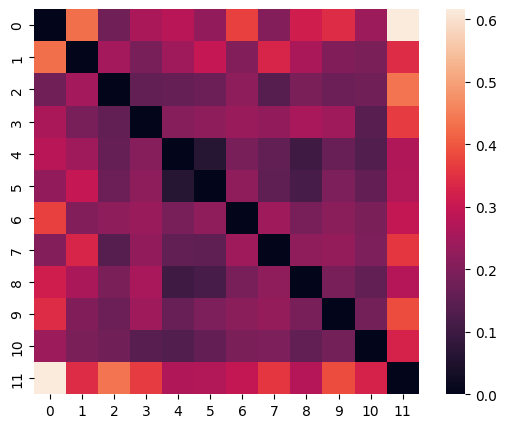

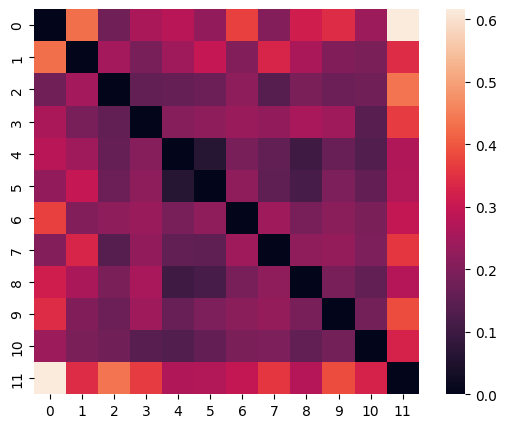

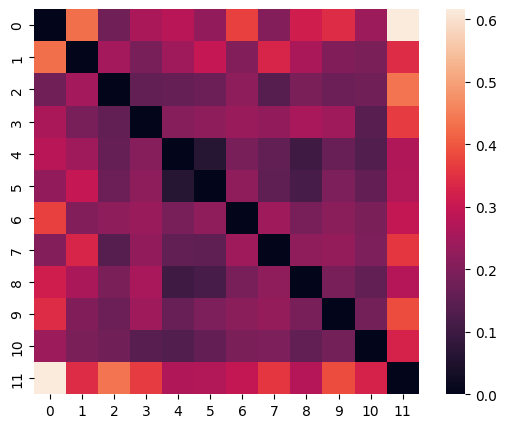

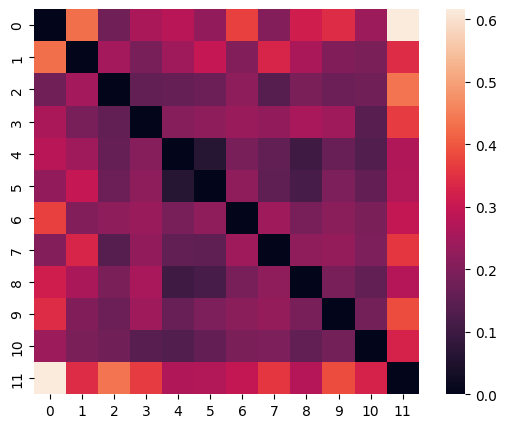

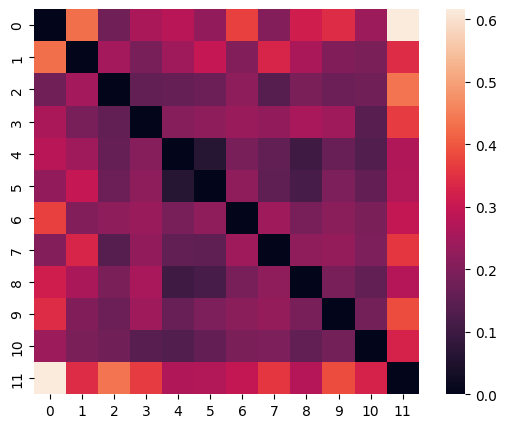

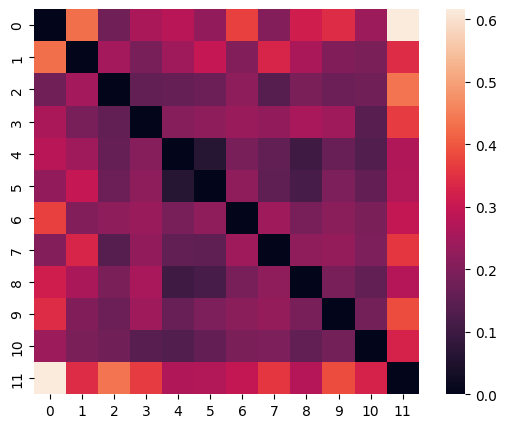

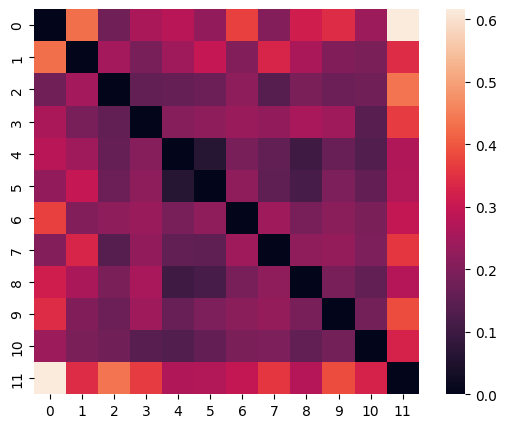

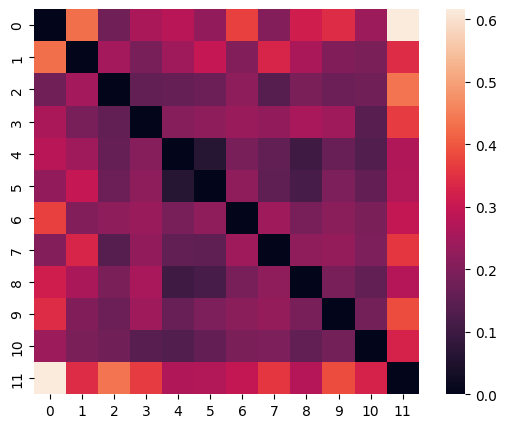

In [12]:
####### all

t_items = ['Reeval', 'Certainty', 'Cost', 'If_help', 'Intention', 'Allocation', 'Mood', 'Surprise'] # 'Reeval',

sub7001_data = data[data.X['Subject']==7001]
sub7001_bdata = data.X[data.X['Subject']==7001]

for t_item in t_items:
    print(t_item)
    sub7001_bdata[t_item].values.reshape(-1,1) # 行为数据

    # For one ROI
    ROI_mask = mask_all[mask_all.X['Cluster_num']==1]
    masked_data  = sub7001_data.apply_mask(ROI_mask)    
    ROI_dist = masked_data.distance(metric = 'correlation')
    ROI_dist.plot()

    subID = data.X['Subject'].unique()

    sub_num = len(subID)

    results_r = np.zeros((200,sub_num))
    results_p = np.zeros((200,sub_num))

    for i,sub in enumerate(subID):
        print (t_item, sub)
        sub_data = data[data.X['Subject']==sub]
        sub_bdata = data.X[data.X['Subject']==sub]
        
        pair_dist = pairwise_distances(sub_bdata[t_item].values.reshape(-1, 1), metric = 'euclidean')
        pair_dist = (pair_dist + pair_dist.T)/2
        
        model_dist = Adjacency(pair_dist)
        for k in mask_all.X['Cluster_num']:  
            print (t_item, sub, k)
            ROI_mask = mask_all[mask_all.X['Cluster_num']==k]
            masked_data  =  sub_data.apply_mask(ROI_mask)    
            ROI_dist = masked_data.distance(metric = 'correlation')
            Brain_Beha_corr = ROI_dist.similarity(model_dist,plot = False, n_permute = 10000, metric='spearman')

            results_r[k-1,i] = Brain_Beha_corr['correlation']
            results_p[k-1,i] = Brain_Beha_corr['p']  

    results_dir = 'D:/CBCS_fMRI/LiuXuqi_CMF/04_RSA/20230818_RSA_12Onset/WSRSA_condition_results_20230818_12Onset/'
    results_r_dir = results_dir + 'Withinsubject_RSA_'+ t_item + '_200_r_value.txt'
    results_p_dir = results_dir + 'Withinsubject_RSA_'+ t_item + '_200_p_value.txt'

    np.savetxt(results_r_dir,results_r)    
    np.savetxt(results_p_dir,results_p)  

    print(t_item, ' finished!')
    
# t_items = [  'Certainty', 'Cost', 'Intention', 'Gratitude', 'Allocation'] # 'Reeval',

In [ ]:
#

In [11]:
results_dir = 'D:/CBCS_fMRI/LiuXuqi_CMF/04_RSA/20230818_RSA_12Onset/WSRSA_condition_results_20230818_12Onset/'

if os.path.exists(results_dir):
    print(f"The directory '{results_dir}' exists.")

The directory 'D:/CBCS_fMRI/LiuXuqi_CMF/04_RSA/20230818_RSA_12Onset/WSRSA_condition_results_20230818_12Onset/' exists.


In [21]:
results_dir = 'D:/CBCS_fMRI/LiuXuqi_CMF/04_RSA/20230810_RSA_6Onset/WSRSA_condition_results_20230810_6Onset/'
results_r_dir = results_dir + 'Withinsubject_RSA_'+ t_item + '_200_r_value.txt'
results_p_dir = results_dir + 'Withinsubject_RSA_'+ t_item + '_200_p_value.txt'

np.savetxt(results_r_dir,results_r)    
np.savetxt(results_p_dir,results_p)  

# test (because pairwise_distances seems not to generate the symmetric matrix)

# subID = 7003
# sub_data = data[data.X['Subject']==subID]
# sub_bdata = data.X[data.X['Subject']==subID]

# pair_dist = pairwise_distances(sub_bdata["Allocation"].values.reshape(-1, 1), metric = 'euclidean')
# print(pair_dist)
# # print(pair_dist.T - pair_dist)
# pair_dist = (pair_dist + pair_dist.T)/2
# print(pair_dist)

# model_dist = Adjacency(pair_dist)

# print(type(pairwise_distances(sub_bdata["Allocation"].values.reshape(-1, 1), metric = 'euclidean')))
# print(model_dist)

Reeval 0.03259348130373925
Reeval 197  (sig)
Certainty 0.022795440911817635
Certainty 93  (sig)
Cost 0.04099180163967207
Cost 194  (sig)
If_help 0.04439112177564487
If_help 177  (sig)
Intention 0.0001999600079984003
Intention 0  (sig)


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\nilearn\plotting\displays\_slicers.py:382: UserWarning: empty mask
  get_mask_bounds(new_img_like(img, not_mask, affine))


Allocation 0.041991601679664065
Allocation 170  (sig)
Mood 0.014397120575884824
Mood 59  (sig)
Surprise 0.0001999600079984003
Surprise 0  (sig)


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\nilearn\plotting\displays\_slicers.py:382: UserWarning: empty mask
  get_mask_bounds(new_img_like(img, not_mask, affine))


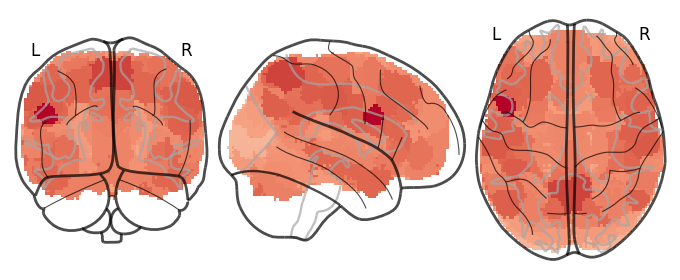

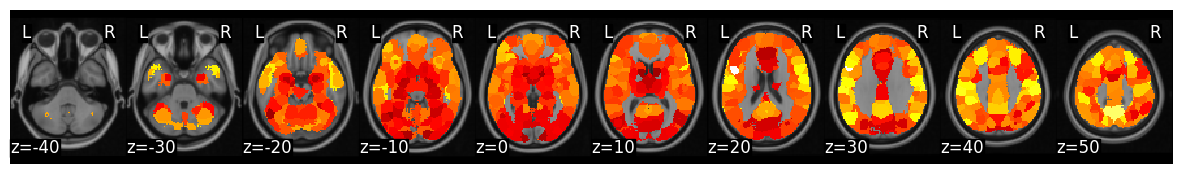

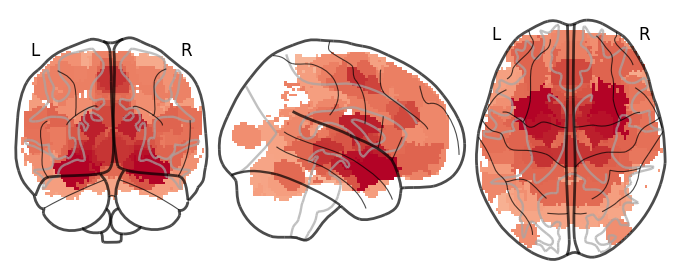

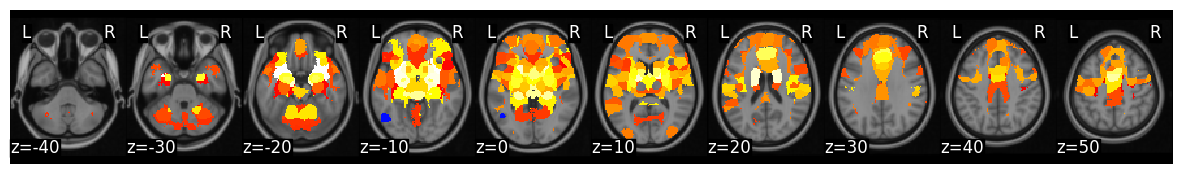

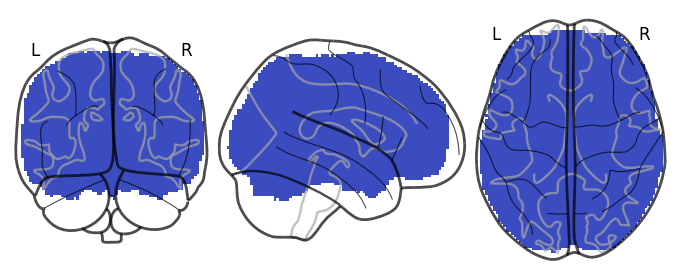

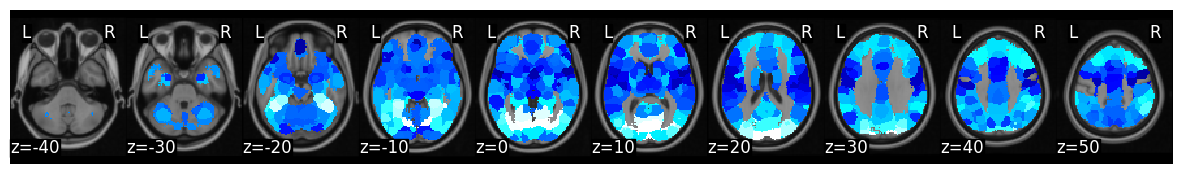

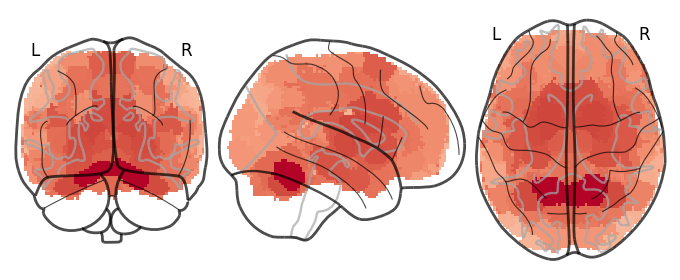

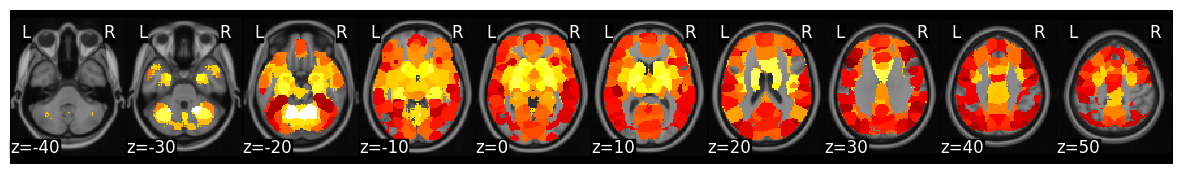

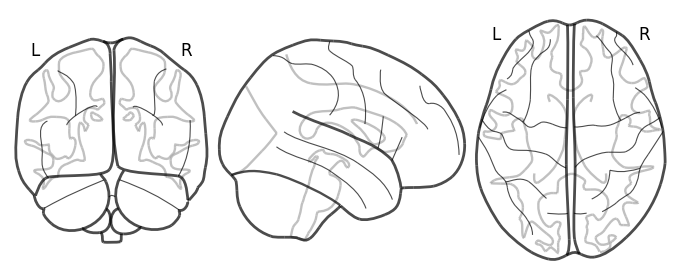

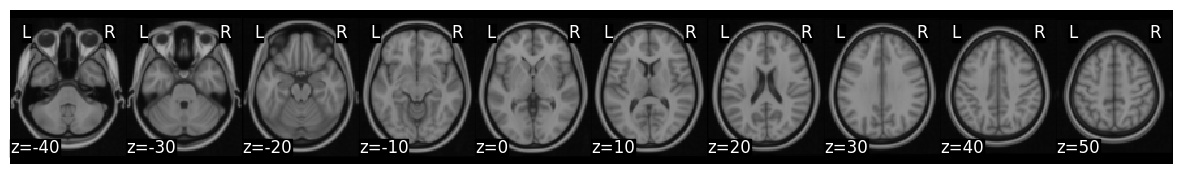

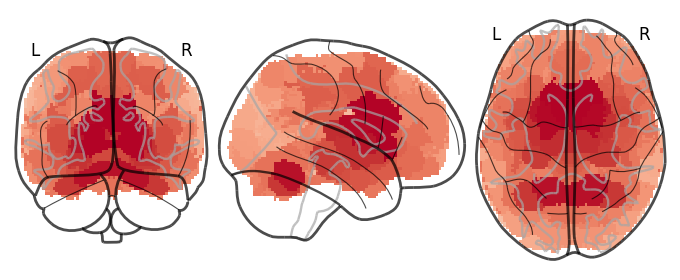

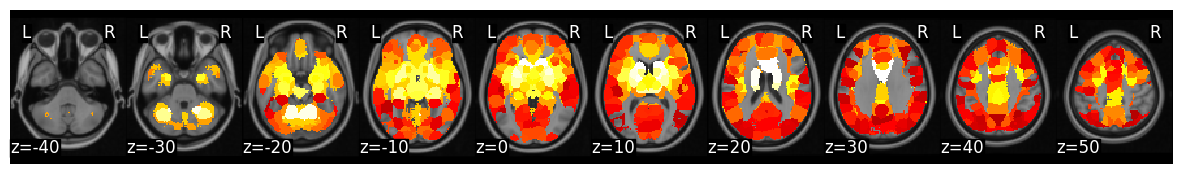

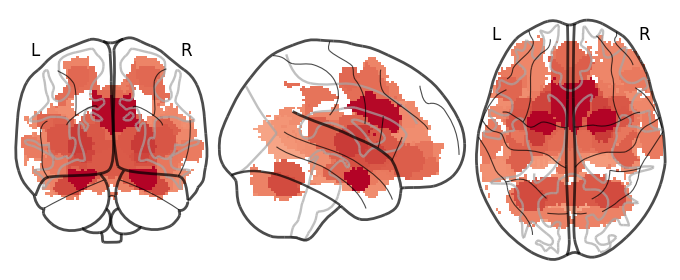

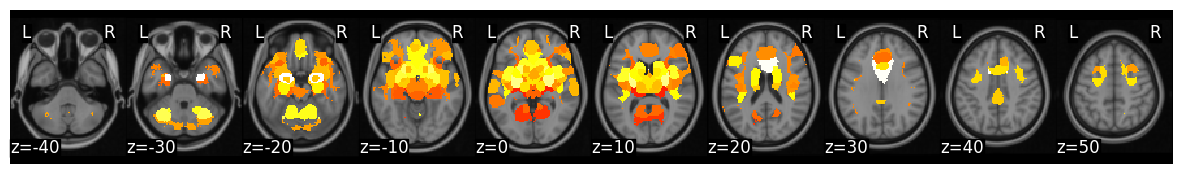

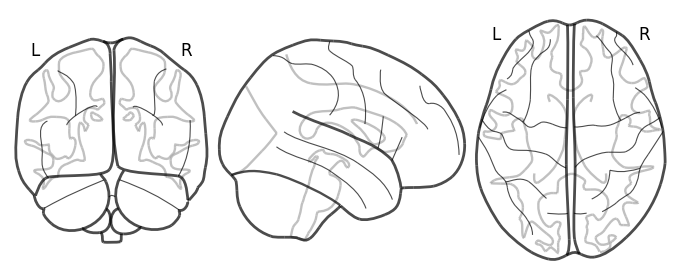

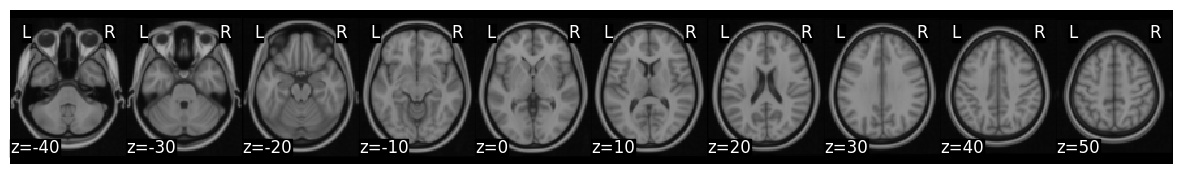

In [13]:
threshold_list = []
rsa_p_list = []
# t_items = [  'Reeval', 'Certainty', 'Cost', 'Intention', 'Gratitude', 'Allocation'] # 'Reeval',

t_items = ['Reeval', 'Certainty', 'Cost', 'If_help', 'Intention', 'Allocation', 'Mood', 'Surprise'] # 'Reeval',

for t_item in t_items:
    rsa_stats = []
    
    results_dir = 'D:\\CBCS_fMRI\\LiuXuqi_CMF\\04_RSA\\20230818_RSA_12Onset\\WSRSA_condition_results_20230818_12Onset\\'
    results_r_dir = results_dir + 'Withinsubject_RSA_'+ t_item + '_200_r_value.txt'
    results_p_dir = results_dir + 'Withinsubject_RSA_'+ t_item + '_200_p_value.txt'
    
    results_r = np.loadtxt(results_r_dir,delimiter = ' ', skiprows = 0)
    results_p = np.loadtxt(results_p_dir,delimiter = ' ', skiprows = 0)

    for k in mask_all.X['Cluster_num']:
        rsa_stats.append(one_sample_permutation(np.array(fisher_r_to_z(results_r[k-1,:])),n_permute=5000))

    rsa_p_list.append(rsa_stats)
    
    fdr_p = fdr(np.array([x['p'] for x in rsa_stats]), q=0.05)
    print(t_item, fdr_p)
    
    count = sum(1 for x in rsa_stats if x['p'] < fdr_p)
    print(t_item, count, " (sig)")

    rsa_r = Brain_Data([x*y['mean'] for x,y in zip(mask_all, rsa_stats)]).sum()
    rsa_p = Brain_Data([x*y['p'] for x,y in zip(mask_all, rsa_stats)]).sum()

    thresholded = threshold(rsa_r, rsa_p, thr=fdr_p)

    plot_glass_brain(thresholded.to_nifti(), cmap='coolwarm')

    thresholded.write(os.path.join(results_dir,str('Withinsubject_RSA_' + t_item + '_200_fdr.nii.gz')))

    thresholded.plot()
    
    threshold_list.append(thresholded)
    
    # t_items = [  'Reeval', 'Certainty', 'Cost', 'Intention', 'Gratitude', 'Allocation'] # 'Reeval',

In [5]:
results_r_dir = results_dir + 'Withinsubject_RSA_Gratitude_200_r_value.txt'

results_r = np.loadtxt(results_r_dir,delimiter = ' ', skiprows = 0)

In [11]:
# for i in range(len(results_r[118])):
#     print(results_r[118][i],',')

In [20]:
one_sample_permutation(np.array(fisher_r_to_z(results_r[51,:])),n_permute=1000)

{'mean': 0.051278478995045534, 'p': 0.08391608391608392}

In [15]:
fisher_r_to_z(results_r[51,:])

array([ 0.28402743, -0.1284919 ,  0.01057085,  0.5500589 ,  0.0168139 ,
        0.02110279,  0.08733462, -0.18623966, -0.1172469 ,  0.63064904,
        0.10148884, -0.08634614, -0.15000625, -0.01908985,  0.30099553,
        0.20773238,  0.10071389,  0.14802268,  0.14761061,  0.0490529 ,
       -0.02851963,  0.05953599,  0.04434963, -0.14240824, -0.12574943,
        0.14720958,  0.00616885,  0.35094524,  0.02553409, -0.0901029 ,
        0.01136347,  0.01280552, -0.09159015, -0.09475719,  0.14560318,
       -0.12354944, -0.02085809,  0.45720234, -0.02651182, -0.06427534,
       -0.04668969, -0.13543421,  0.50240867, -0.13414294, -0.17454375,
       -0.07393737])

In [16]:
results_r[51,:]

array([ 0.27662845, -0.1277894 ,  0.01057046,  0.50056435,  0.01681232,
        0.02109965,  0.08711325, -0.18411587, -0.11671258,  0.55849897,
        0.10114183, -0.08613219, -0.14889115, -0.01908753,  0.2922234 ,
        0.204795  ,  0.10037475,  0.14695098,  0.14654778,  0.04901359,
       -0.0285119 ,  0.05946575,  0.04432058, -0.1414533 , -0.12509077,
        0.14615534,  0.00616878,  0.33721356,  0.02552855, -0.08985985,
        0.01136298,  0.01280482, -0.0913349 , -0.0944746 ,  0.14458289,
       -0.12292461, -0.02085506,  0.4278013 , -0.02650561, -0.06418697,
       -0.04665579, -0.13461218,  0.46400934, -0.13334409, -0.17279257,
       -0.07380293])